In [24]:
# # ============================================================
# # CELL 1 — ENVIRONMENT SETUP
# # ============================================================
# import os

# # ✅ FIX 1: Point Torch model cache to /kaggle/working so pretrained
# # weights survive the session and never re-download.
# os.environ['TORCH_HOME'] = '/kaggle/working/.torch_cache'
# os.makedirs('/kaggle/working/.torch_cache', exist_ok=True)

# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [25]:
# ============================================================
# CELL 2 — INSTALL PACKAGES & GLOBAL IMPORTS
# ============================================================
!pip install -q albumentations timm plotly kaleido

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models
from torchvision.models import (
    DenseNet121_Weights, ResNet50_Weights, MobileNet_V2_Weights
)
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler   # ✅ FIX 2: Mixed Precision
import timm
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings, gc
warnings.filterwarnings('ignore')

# ✅ FIX 3: cuDNN benchmark — lets CUDA auto-tune kernels for your GPU
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False  # slightly faster than deterministic

# Plotting style
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()   # AMP only makes sense on GPU

print(f"🎯 Device  : {device}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   AMP     : {'✅ ENABLED' if USE_AMP else '❌ CPU mode — disabled'}")
print(f"   torch   : {torch.__version__}")
print(f"   albu    : {A.__version__}")
print(f"   timm    : {timm.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.1 MB/s eta 0:00:00
🎯 Device  : cuda
   GPU     : Tesla T4
   Memory  : 15.6 GB
   AMP     : ✅ ENABLED
   torch   : 2.10.0+cu128
   albu    : 2.0.8
   timm    : 1.0.25


In [26]:
# ============================================================
# CELL 3 — DATASET EXPLORATION (EDA)
# ============================================================
def explore_rice_dataset():
    print("🌾 RICE DISEASE DETECTION SYSTEM")
    print("=" * 45)

    rice_base_path = Path("/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease")
    rice_class_counts = {}
    rice_total = 0

    for split in ['train', 'validation']:
        split_path = rice_base_path / split
        if split_path.exists():
            print(f"\n📂 {split.upper()} SPLIT:")
            for disease_folder in sorted(split_path.iterdir()):
                if disease_folder.is_dir():
                    images = list(disease_folder.glob('*.jpg')) + list(disease_folder.glob('*.png'))
                    if images:
                        class_name = disease_folder.name.lower()
                        rice_class_counts[class_name] = rice_class_counts.get(class_name, 0) + len(images)
                        rice_total += len(images)
                        print(f"   📁 {disease_folder.name:<30} {len(images):>5} images")

    print(f"\n{'─'*45}")
    print(f"📊 DATASET SUMMARY")
    print(f"   Total Classes : {len(rice_class_counts)}")
    print(f"   Total Images  : {rice_total:,}")
    print(f"{'─'*45}")
    for class_name, count in rice_class_counts.items():
        pct = (count / rice_total) * 100
        bar = '█' * int(pct / 2)
        print(f"   {class_name.replace('_', ' ').title():<25} {count:>5} ({pct:5.1f}%)  {bar}")

    return rice_class_counts, rice_total

rice_classes, total_images = explore_rice_dataset()

🌾 RICE DISEASE DETECTION SYSTEM

📂 TRAIN SPLIT:
   📁 bacterial_leaf_blight             59 images
   📁 brown_spot                       314 images
   📁 healthy                          350 images
   📁 leaf_blast                       350 images
   📁 leaf_scald                       350 images
   📁 narrow_brown_spot                350 images

📂 VALIDATION SPLIT:
   📁 bacterial_leaf_blight             19 images
   📁 brown_spot                        76 images
   📁 healthy                           88 images
   📁 leaf_blast                        88 images
   📁 leaf_scald                        88 images
   📁 narrow_brown_spot                 88 images

─────────────────────────────────────────────
📊 DATASET SUMMARY
   Total Classes : 6
   Total Images  : 2,220
─────────────────────────────────────────────
   Bacterial Leaf Blight        78 (  3.5%)  █
   Brown Spot                  390 ( 17.6%)  ████████
   Healthy                     438 ( 19.7%)  █████████
   Leaf Blast                 

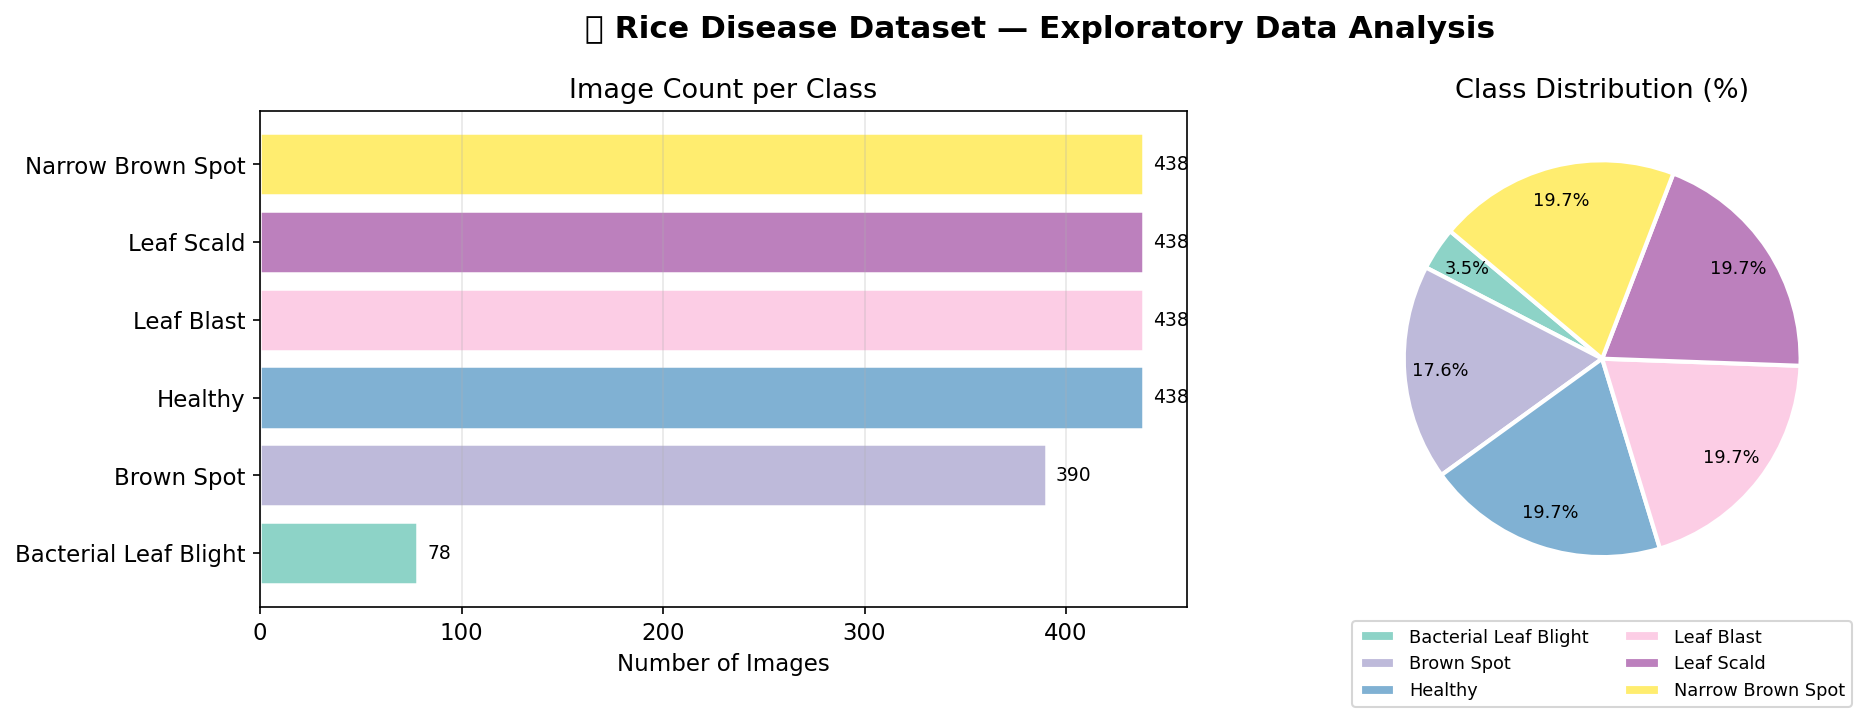

✅ EDA plot saved.


In [27]:
# ============================================================
# CELL 4 — EDA VISUALIZATIONS
# ============================================================
def plot_eda(rice_classes):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('🌾 Rice Disease Dataset — Exploratory Data Analysis',
                 fontsize=15, fontweight='bold')

    names  = [k.replace('_', ' ').title() for k in rice_classes]
    counts = list(rice_classes.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(names)))

    bars = axes[0].barh(names, counts, color=colors, edgecolor='white', linewidth=1.2)
    axes[0].set_xlabel('Number of Images')
    axes[0].set_title('Image Count per Class')
    for bar, cnt in zip(bars, counts):
        axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                     f'{cnt:,}', va='center', fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    wedges, texts, autotexts = axes[1].pie(
        counts, labels=None, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.82,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_fontsize(8.5)
    axes[1].legend(wedges, names, loc='lower center', ncol=2,
                   bbox_to_anchor=(0.5, -0.22), fontsize=8.5)
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ EDA plot saved.")

plot_eda(rice_classes)

In [28]:
# ============================================================
# CELL 5 — DATA COLLECTION & SPLITS (70 / 20 / 10)
# ============================================================
def collect_rice_data():
    print("\n📊 COLLECTING RICE DISEASE DATA")
    print("=" * 40)

    all_images, all_labels = [], []
    class_mapping = {}
    class_id = 0
    rice_base = Path("/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease")

    for split in ['train', 'validation']:
        split_path = rice_base / split
        if split_path.exists():
            for disease_folder in sorted(split_path.iterdir()):
                if disease_folder.is_dir():
                    class_name = disease_folder.name.lower()
                    if class_name not in class_mapping.values():
                        class_mapping[class_id] = class_name
                        current_id = class_id
                        class_id += 1
                    else:
                        current_id = next(k for k, v in class_mapping.items() if v == class_name)
                    images = list(disease_folder.glob('*.jpg')) + list(disease_folder.glob('*.png'))
                    all_images.extend(images)
                    all_labels.extend([current_id] * len(images))
                    print(f"   ✅ [{split}] {class_name:<30} {len(images):>5} images")

    print(f"\n   Total images  : {len(all_images):,}")
    print(f"   Total classes : {len(class_mapping)}")

    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_labels, test_size=0.10, stratify=all_labels, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.222, stratify=y_temp, random_state=42)

    splits = {
        'train': (X_train, y_train),
        'val':   (X_val,   y_val),
        'test':  (X_test,  y_test),
    }
    print(f"\n{'─'*40}")
    print("📊 SPLIT BREAKDOWN (70 / 20 / 10)")
    for sname, (imgs, lbls) in splits.items():
        print(f"   {sname.capitalize():<8} : {len(imgs):>5,} images")
    return splits, class_mapping

splits, class_mapping = collect_rice_data()
num_classes = len(class_mapping)
CLASS_NAMES = [class_mapping[i].replace('_', ' ').title() for i in range(num_classes)]


📊 COLLECTING RICE DISEASE DATA
   ✅ [train] bacterial_leaf_blight             59 images
   ✅ [train] brown_spot                       314 images
   ✅ [train] healthy                          350 images
   ✅ [train] leaf_blast                       350 images
   ✅ [train] leaf_scald                       350 images
   ✅ [train] narrow_brown_spot                350 images
   ✅ [validation] bacterial_leaf_blight             19 images
   ✅ [validation] brown_spot                        76 images
   ✅ [validation] healthy                           88 images
   ✅ [validation] leaf_blast                        88 images
   ✅ [validation] leaf_scald                        88 images
   ✅ [validation] narrow_brown_spot                 88 images

   Total images  : 2,220
   Total classes : 6

────────────────────────────────────────
📊 SPLIT BREAKDOWN (70 / 20 / 10)
   Train    : 1,554 images
   Val      :   444 images
   Test     :   222 images


In [29]:
import os
# ============================================================
# CELL 6 — DATASET CLASS & DATA AUGMENTATION
# ============================================================
class RiceDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        # ✅ FIX 4: Pre-convert paths to strings once — saves repeated str() calls
        self.image_paths = [str(p) for p in image_paths]
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, self.labels[idx]


# ── Version-safe CoarseDropout ─────────────────────────────
def _make_coarse_dropout(p=0.3):
    _ver = tuple(int(x) for x in A.__version__.split('.')[:2])
    if _ver >= (2, 0):
        return A.CoarseDropout(num_holes_range=(1, 8),
                               hole_height_range=(1, 32),
                               hole_width_range=(1, 32), p=p)
    return A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                           min_holes=1, min_height=1, min_width=1, p=p)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.OneOf([A.MotionBlur(p=0.3), A.MedianBlur(blur_limit=3, p=0.2),
             A.Blur(blur_limit=3, p=0.2)], p=0.3),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=15, p=0.3),
    _make_coarse_dropout(p=0.3),
    A.OneOf([A.OpticalDistortion(p=0.3), A.GridDistortion(p=0.1),
             A.ElasticTransform(p=0.3)], p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

# ── Datasets ────────────────────────────────────────────────
train_dataset = RiceDiseaseDataset(splits['train'][0], splits['train'][1], train_transform)
val_dataset   = RiceDiseaseDataset(splits['val'][0],   splits['val'][1],   val_transform)
test_dataset  = RiceDiseaseDataset(splits['test'][0],  splits['test'][1],  val_transform)

# ✅ FIX 5: num_workers=4, persistent_workers + prefetch_factor=2
# persistent_workers avoids respawning workers each epoch (big speedup)
# prefetch_factor=2 means workers pre-load 2 batches ahead of the GPU
BATCH_SIZE  = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

print("✅ DATASETS & DATALOADERS READY")
print(f"   Train   : {len(train_dataset):,} samples  ({len(train_loader)} batches)")
print(f"   Val     : {len(val_dataset):,} samples  ({len(val_loader)} batches)")
print(f"   Test    : {len(test_dataset):,} samples  ({len(test_loader)} batches)")
print(f"   Workers : {NUM_WORKERS}  |  Batch: {BATCH_SIZE}  |  persistent_workers: True")

✅ DATASETS & DATALOADERS READY
   Train   : 1,554 samples  (49 batches)
   Val     : 444 samples  (14 batches)
   Test    : 222 samples  (7 batches)
   Workers : 4  |  Batch: 32  |  persistent_workers: True


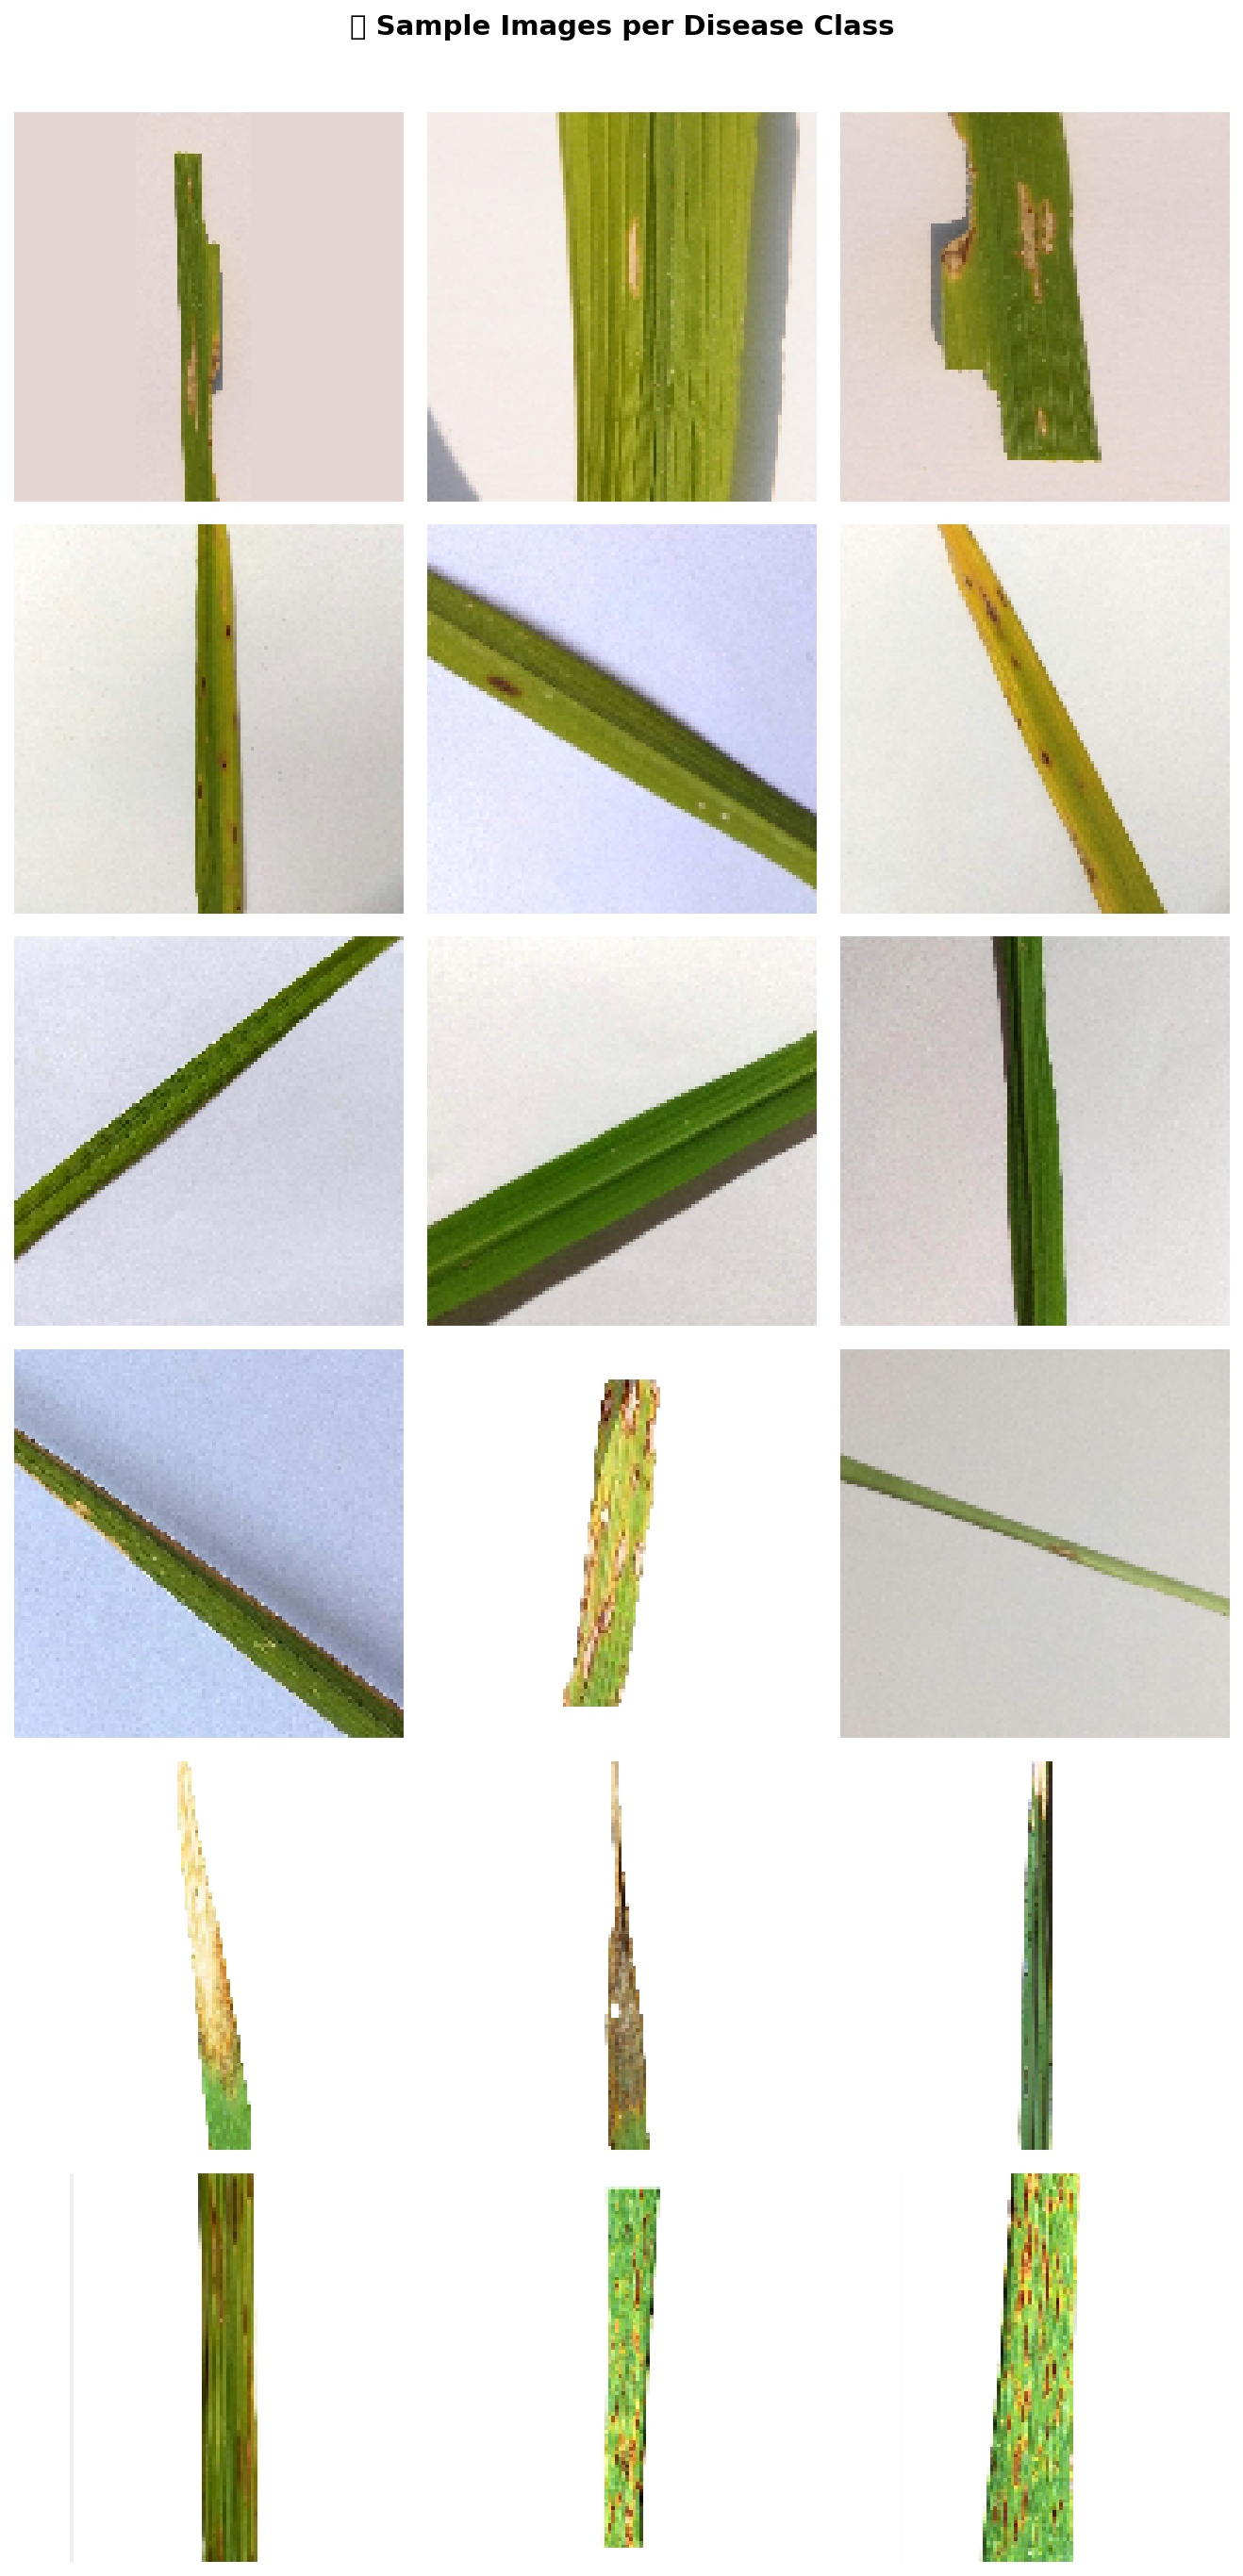

✅ Sample image grid saved.


In [30]:
# ============================================================
# CELL 7 — VISUALISE SAMPLE IMAGES
# ============================================================
def show_sample_images(dataset, class_mapping, n_per_class=3):
    n_classes = len(class_mapping)
    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 3, n_classes * 3))
    fig.suptitle('🌿 Sample Images per Disease Class', fontsize=14,
                 fontweight='bold', y=1.01)

    class_indices = {c: [] for c in range(n_classes)}
    for i, lbl in enumerate(dataset.labels):
        class_indices[lbl].append(i)

    for cls_id in range(n_classes):
        chosen = np.random.choice(
            class_indices[cls_id],
            min(n_per_class, len(class_indices[cls_id])),
            replace=False
        )
        for col, img_idx in enumerate(chosen):
            img = cv2.imread(dataset.image_paths[img_idx])
            if img is None:
                img = np.zeros((112, 112, 3), dtype=np.uint8)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (112, 112))
            ax = axes[cls_id, col] if n_classes > 1 else axes[col]
            ax.imshow(img); ax.axis('off')
            if col == 0:
                ax.set_ylabel(class_mapping[cls_id].replace('_', '\n').title(),
                              fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Sample image grid saved.")

show_sample_images(train_dataset, class_mapping, n_per_class=3)

In [31]:
# ============================================================
# CELL 8 — MODEL FACTORY
# ✅ FIX 6: Cache check — skip download if weights already saved locally
# ============================================================
CACHE_DIR = Path('/kaggle/working/.torch_cache')

# ✅ Create cache directory if it doesn't exist
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cached_densenet121(n):
    local = CACHE_DIR / 'densenet121.pth'
    m = models.densenet121(weights=None)
    m.classifier = nn.Linear(m.classifier.in_features, n)
    if local.exists():
        print("   DenseNet-121  : ✅ loaded from cache")
        # Load backbone weights only (ignore classifier mismatch)
        state = torch.load(local, map_location='cpu')
        # Filter out classifier keys so we can load backbone
        backbone_state = {k: v for k, v in state.items() if 'classifier' not in k}
        m.load_state_dict(backbone_state, strict=False)
    else:
        print("   DenseNet-121  : ⬇️  downloading pretrained weights...")
        m_pretrained = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
        # Save backbone (not classifier)
        backbone_state = {k: v for k, v in m_pretrained.state_dict().items() if 'classifier' not in k}
        torch.save(backbone_state, local)
        m.load_state_dict(backbone_state, strict=False)
        del m_pretrained
    return m

def _cached_resnet50(n):
    local = CACHE_DIR / 'resnet50.pth'
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, n)
    if local.exists():
        print("   ResNet-50     : ✅ loaded from cache")
        state = torch.load(local, map_location='cpu')
        m.load_state_dict(state, strict=False)
    else:
        print("   ResNet-50     : ⬇️  downloading pretrained weights...")
        m_pretrained = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        backbone_state = {k: v for k, v in m_pretrained.state_dict().items() if 'fc' not in k}
        torch.save(backbone_state, local)
        m.load_state_dict(backbone_state, strict=False)
        del m_pretrained
    return m

def _cached_mobilenetv2(n):
    local = CACHE_DIR / 'mobilenetv2.pth'
    m = models.mobilenet_v2(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    if local.exists():
        print("   MobileNetV2   : ✅ loaded from cache")
        state = torch.load(local, map_location='cpu')
        m.load_state_dict(state, strict=False)
    else:
        print("   MobileNetV2   : ⬇️  downloading pretrained weights...")
        m_pretrained = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        backbone_state = {k: v for k, v in m_pretrained.state_dict().items() if 'classifier.1' not in k}
        torch.save(backbone_state, local)
        m.load_state_dict(backbone_state, strict=False)
        del m_pretrained
    return m

def _cached_efficientnet_b0(n):
    local = CACHE_DIR / 'efficientnet_b0.pth'
    if local.exists():
        print("   EfficientNetB0: ✅ loaded from cache")
        m = timm.create_model('efficientnet_b0', pretrained=False, num_classes=n)
        state = torch.load(local, map_location='cpu')
        m.load_state_dict(state, strict=False)
    else:
        print("   EfficientNetB0: ⬇️  downloading pretrained weights...")
        m = timm.create_model('efficientnet_b0', pretrained=True, num_classes=n)
        # Save backbone (timm stores classifier as 'classifier' layer)
        backbone_state = {k: v for k, v in m.state_dict().items() if 'classifier' not in k}
        torch.save(backbone_state, local)
    return m

print("🔧 Building models (using cache when available)...")
models_config = {
    'DenseNet-121':    {'model': _cached_densenet121(num_classes).to(device)},
    'ResNet-50':       {'model': _cached_resnet50(num_classes).to(device)},
    'MobileNetV2':     {'model': _cached_mobilenetv2(num_classes).to(device)},
    'EfficientNet-B0': {'model': _cached_efficientnet_b0(num_classes).to(device)},
}

for name, cfg in models_config.items():
    cfg['optimizer'] = optim.Adam(cfg['model'].parameters(), lr=1e-3, weight_decay=1e-4)
    cfg['scheduler'] = optim.lr_scheduler.ReduceLROnPlateau(
        cfg['optimizer'], mode='max', factor=0.5, patience=3
    )
    # ✅ FIX 7: One GradScaler per model for stable AMP training
    cfg['scaler'] = GradScaler(enabled=USE_AMP)

print("\n✅ MODELS INITIALISED")
print(f"{'Model':<20} {'Total Params':>15} {'Trainable':>15}")
print('─' * 52)
for name, cfg in models_config.items():
    total     = sum(p.numel() for p in cfg['model'].parameters())
    trainable = sum(p.numel() for p in cfg['model'].parameters() if p.requires_grad)
    print(f"{name:<20} {total:>15,} {trainable:>15,}")

🔧 Building models (using cache when available)...
   DenseNet-121  : ⬇️  downloading pretrained weights...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 155MB/s] 


   ResNet-50     : ⬇️  downloading pretrained weights...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


   MobileNetV2   : ⬇️  downloading pretrained weights...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s] 


   EfficientNetB0: ⬇️  downloading pretrained weights...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


✅ MODELS INITIALISED
Model                   Total Params       Trainable
────────────────────────────────────────────────────
DenseNet-121               6,960,006       6,960,006
ResNet-50                 23,520,326      23,520,326
MobileNetV2                2,231,558       2,231,558
EfficientNet-B0            4,015,234       4,015,234


In [32]:
# ============================================================
# CELL 9 — OPTIMIZED TRAINER WITH AMP + EARLY STOPPING
# ============================================================
class RiceTrainer:
    """
    Key optimizations vs original:
      ✅ Mixed Precision (autocast + GradScaler) — ~2x faster on GPU
      ✅ Early stopping — stops when val accuracy plateaus
      ✅ Gradient clipping — prevents exploding gradients with AMP
    """
    def __init__(self, model, optimizer, scheduler, scaler):
        self.model     = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.scaler    = scaler
        self.criterion = nn.CrossEntropyLoss()
        self.train_losses, self.val_losses = [], []
        self.train_accs,   self.val_accs   = [], []
        self.learning_rates                = []

    # ── Single epoch pass ───────────────────────────────────
    def _run_epoch(self, loader, training=True):
        if training:
            self.model.train()
        else:
            self.model.eval()

        total_loss, correct, total = 0.0, 0, 0
        all_preds, all_targets     = [], []
        desc = 'Train' if training else 'Val  '

        ctx = torch.no_grad() if not training else torch.enable_grad()
        with ctx:
            for data, target in tqdm(loader, desc=f'  {desc}', leave=False):
                data, target = data.to(device, non_blocking=True), \
                               target.to(device, non_blocking=True)

                # ✅ FIX 8: autocast enables FP16 compute on GPU
                with autocast(enabled=USE_AMP):
                    output = self.model(data)
                    loss   = self.criterion(output, target)

                if training:
                    self.optimizer.zero_grad(set_to_none=True)  # faster than zero_grad()
                    # ✅ FIX 9: scaler handles FP16 gradient scaling
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()

                total_loss += loss.item()
                preds = output.argmax(1)
                correct += preds.eq(target).sum().item()
                total   += target.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(target.cpu().numpy())

        return total_loss / len(loader), 100.0 * correct / total, all_preds, all_targets

    # ── Full training loop with early stopping ───────────────
    def train_model(self, epochs=10, patience=5):
        """
        patience: stop if val accuracy doesn't improve for this many epochs.
        """
        best_acc              = 0.0
        best_preds            = []
        best_targets          = []
        no_improve_count      = 0

        print(f"  {'Epoch':>5}  {'TrLoss':>7}  {'TrAcc':>7}  "
              f"{'ValLoss':>7}  {'ValAcc':>7}  {'LR':>9}")
        print(f"  {'─'*5}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*9}")

        for ep in range(1, epochs + 1):
            tr_loss, tr_acc, _, _                = self._run_epoch(train_loader, training=True)
            va_loss, va_acc, vpreds, vtargets    = self._run_epoch(val_loader,   training=False)

            self.scheduler.step(va_acc)
            lr = self.optimizer.param_groups[0]['lr']

            self.train_losses.append(tr_loss)
            self.val_losses.append(va_loss)
            self.train_accs.append(tr_acc)
            self.val_accs.append(va_acc)
            self.learning_rates.append(lr)

            improved = va_acc > best_acc
            marker   = ' ✅' if improved else ''
            print(f"  {ep:>5}  {tr_loss:>7.4f}  {tr_acc:>6.2f}%  "
                  f"{va_loss:>7.4f}  {va_acc:>6.2f}%  {lr:>9.6f}{marker}")

            if improved:
                best_acc     = va_acc
                best_preds   = vpreds
                best_targets = vtargets
                no_improve_count = 0
            else:
                no_improve_count += 1

            # ✅ FIX 10: Early stopping
            if no_improve_count >= patience:
                print(f"  ⏹️  Early stopping at epoch {ep} "
                      f"(no improvement for {patience} epochs)")
                break

        return {
            'train_losses':   self.train_losses,
            'val_losses':     self.val_losses,
            'train_accs':     self.train_accs,
            'val_accs':       self.val_accs,
            'learning_rates': self.learning_rates,
            'best_val_acc':   best_acc,
            'val_preds':      best_preds,
            'val_targets':    best_targets,
        }

print("✅ Optimized Trainer class ready.")
print("   Optimizations: AMP · GradScaler · grad-clip · early-stopping · non_blocking transfers")

✅ Optimized Trainer class ready.
   Optimizations: AMP · GradScaler · grad-clip · early-stopping · non_blocking transfers


In [33]:
# ============================================================
# CELL 10 — TEST EVALUATION HELPER
# ============================================================
def evaluate_on_test(model, loader):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for data, target in tqdm(loader, desc='  Test ', leave=False):
            data, target = data.to(device, non_blocking=True), \
                           target.to(device, non_blocking=True)
            # ✅ AMP also speeds up inference
            with autocast(enabled=USE_AMP):
                output = model(data)
            probs = torch.softmax(output.float(), dim=1)
            preds = output.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'accuracy':      accuracy_score(all_targets, all_preds) * 100,
        'precision':     precision_score(all_targets, all_preds, average='weighted') * 100,
        'recall':        recall_score(all_targets, all_preds, average='weighted') * 100,
        'f1_score':      f1_score(all_targets, all_preds, average='weighted') * 100,
        'predictions':   all_preds,
        'targets':       all_targets,
        'probabilities': np.array(all_probs),
    }

print("✅ Evaluation helper ready.")

✅ Evaluation helper ready.


In [34]:
# ============================================================
# CELL 11 — TRAINING LOOP (ALL 4 MODELS)
# ✅ FIX 11: GPU memory cleared between models with gc + cuda.empty_cache
# ============================================================
EPOCHS  = 30 # increased — early stopping will cut short if needed
PATIENCE = 4   # stop if no improvement for 4 consecutive epochs

training_results = {}

print("🌾 TRAINING ALL RICE DISEASE MODELS")
print("=" * 55)
print(f"   Max epochs  : {EPOCHS}  (early stopping patience={PATIENCE})")
print(f"   AMP enabled : {USE_AMP}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Workers     : {NUM_WORKERS}")
print("=" * 55)

for model_name, cfg in models_config.items():
    print(f"\n🔥 {model_name.upper()}")
    print('─' * 55)

    trainer   = RiceTrainer(cfg['model'], cfg['optimizer'],
                            cfg['scheduler'], cfg['scaler'])
    train_res = trainer.train_model(epochs=EPOCHS, patience=PATIENCE)

    print(f"  Evaluating on test set...")
    test_res = evaluate_on_test(cfg['model'], test_loader)

    training_results[model_name] = {**train_res, **test_res}

    # Save trained weights
    save_name = f"rice_{model_name.replace('-','_').lower()}.pth"
    torch.save(cfg['model'].state_dict(), save_name)

    print(f"\n  📊 {model_name} — FINAL METRICS")
    print(f"     Best Val Accuracy : {train_res['best_val_acc']:.2f}%")
    print(f"     Test Accuracy     : {test_res['accuracy']:.2f}%")
    print(f"     Test Precision    : {test_res['precision']:.2f}%")
    print(f"     Test Recall       : {test_res['recall']:.2f}%")
    print(f"     Test F1-Score     : {test_res['f1_score']:.2f}%")
    print(f"     Saved → {save_name}")

    # ✅ FIX 12: Free GPU memory before loading next model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print("\n" + "=" * 55)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")

best_model_name = max(training_results, key=lambda x: training_results[x]['accuracy'])
best_model_acc  = training_results[best_model_name]['accuracy']
print(f"\n🏆 BEST MODEL : {best_model_name}")
print(f"🎯 BEST TEST ACCURACY : {best_model_acc:.2f}%")

🌾 TRAINING ALL RICE DISEASE MODELS
   Max epochs  : 30  (early stopping patience=4)
   AMP enabled : True
   Batch size  : 32
   Workers     : 4

🔥 DENSENET-121
───────────────────────────────────────────────────────
  Epoch   TrLoss    TrAcc  ValLoss   ValAcc         LR
  ─────  ───────  ───────  ───────  ───────  ─────────


      1   1.0461   59.07%   0.7381   79.73%   0.001000 ✅


      2   0.6914   76.13%   0.7238   80.63%   0.001000 ✅


      3   0.5463   80.05%   0.5491   81.53%   0.001000 ✅


      4   0.4918   82.18%   1.2123   61.26%   0.001000


...

      7   0.3642   87.64%   0.3269   85.14%   0.001000


      8   0.2649   90.67%   0.2705   93.02%   0.001000


      9   0.2670   91.44%   0.1377   94.82%   0.001000


     10   0.2163   92.86%   0.1474   95.50%   0.000500
  ⏹️  Early stopping at epoch 10 (no improvement for 4 epochs)
  Evaluating on test set...



  📊 EfficientNet-B0 — FINAL METRICS
     Best Val Accuracy : 96.40%
     Test Accuracy     : 95.50%
     Test Precision    : 95.78%
     Test Recall       : 95.50%
     Test F1-Score     : 95.47%
     Saved → rice_efficientnet_b0.pth

✅ ALL MODELS TRAINED SUCCESSFULLY!

🏆 BEST MODEL : EfficientNet-B0
🎯 BEST TEST ACCURACY : 95.50%


---
# 📊 RESULTS SECTION
### Comprehensive Evaluation — All Models
---

In [35]:
# ============================================================
# RESULT 1 — SUMMARY TABLE
# ============================================================
rows = []
for mname, res in training_results.items():
    rows.append({
        'Model':            mname,
        'Best Val Acc (%)': round(res['best_val_acc'], 2),
        'Test Acc (%)':     round(res['accuracy'],     2),
        'Precision (%)':    round(res['precision'],    2),
        'Recall (%)':       round(res['recall'],       2),
        'F1-Score (%)':     round(res['f1_score'],     2),
        'Epochs Run':       len(res['train_losses']),
    })

results_df = pd.DataFrame(rows).sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)
results_df.index += 1

print("📊 RICE DISEASE DETECTION — MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.to_string())
print("=" * 80)
print(f"\n🏆 Best Model : {results_df.iloc[0]['Model']}")
print(f"🎯 Test Acc   : {results_df.iloc[0]['Test Acc (%)']:.2f}%")

📊 RICE DISEASE DETECTION — MODEL PERFORMANCE SUMMARY
             Model  Best Val Acc (%)  Test Acc (%)  Precision (%)  Recall (%)  F1-Score (%)  Epochs Run
1  EfficientNet-B0             96.40         95.50          95.78       95.50         95.47          10
2      MobileNetV2             93.02         90.54          92.27       90.54         90.29           6
3        ResNet-50             93.02         89.64          91.08       89.64         90.03          12
4     DenseNet-121             94.14         88.29          89.33       88.29         88.09          19

🏆 Best Model : EfficientNet-B0
🎯 Test Acc   : 95.50%


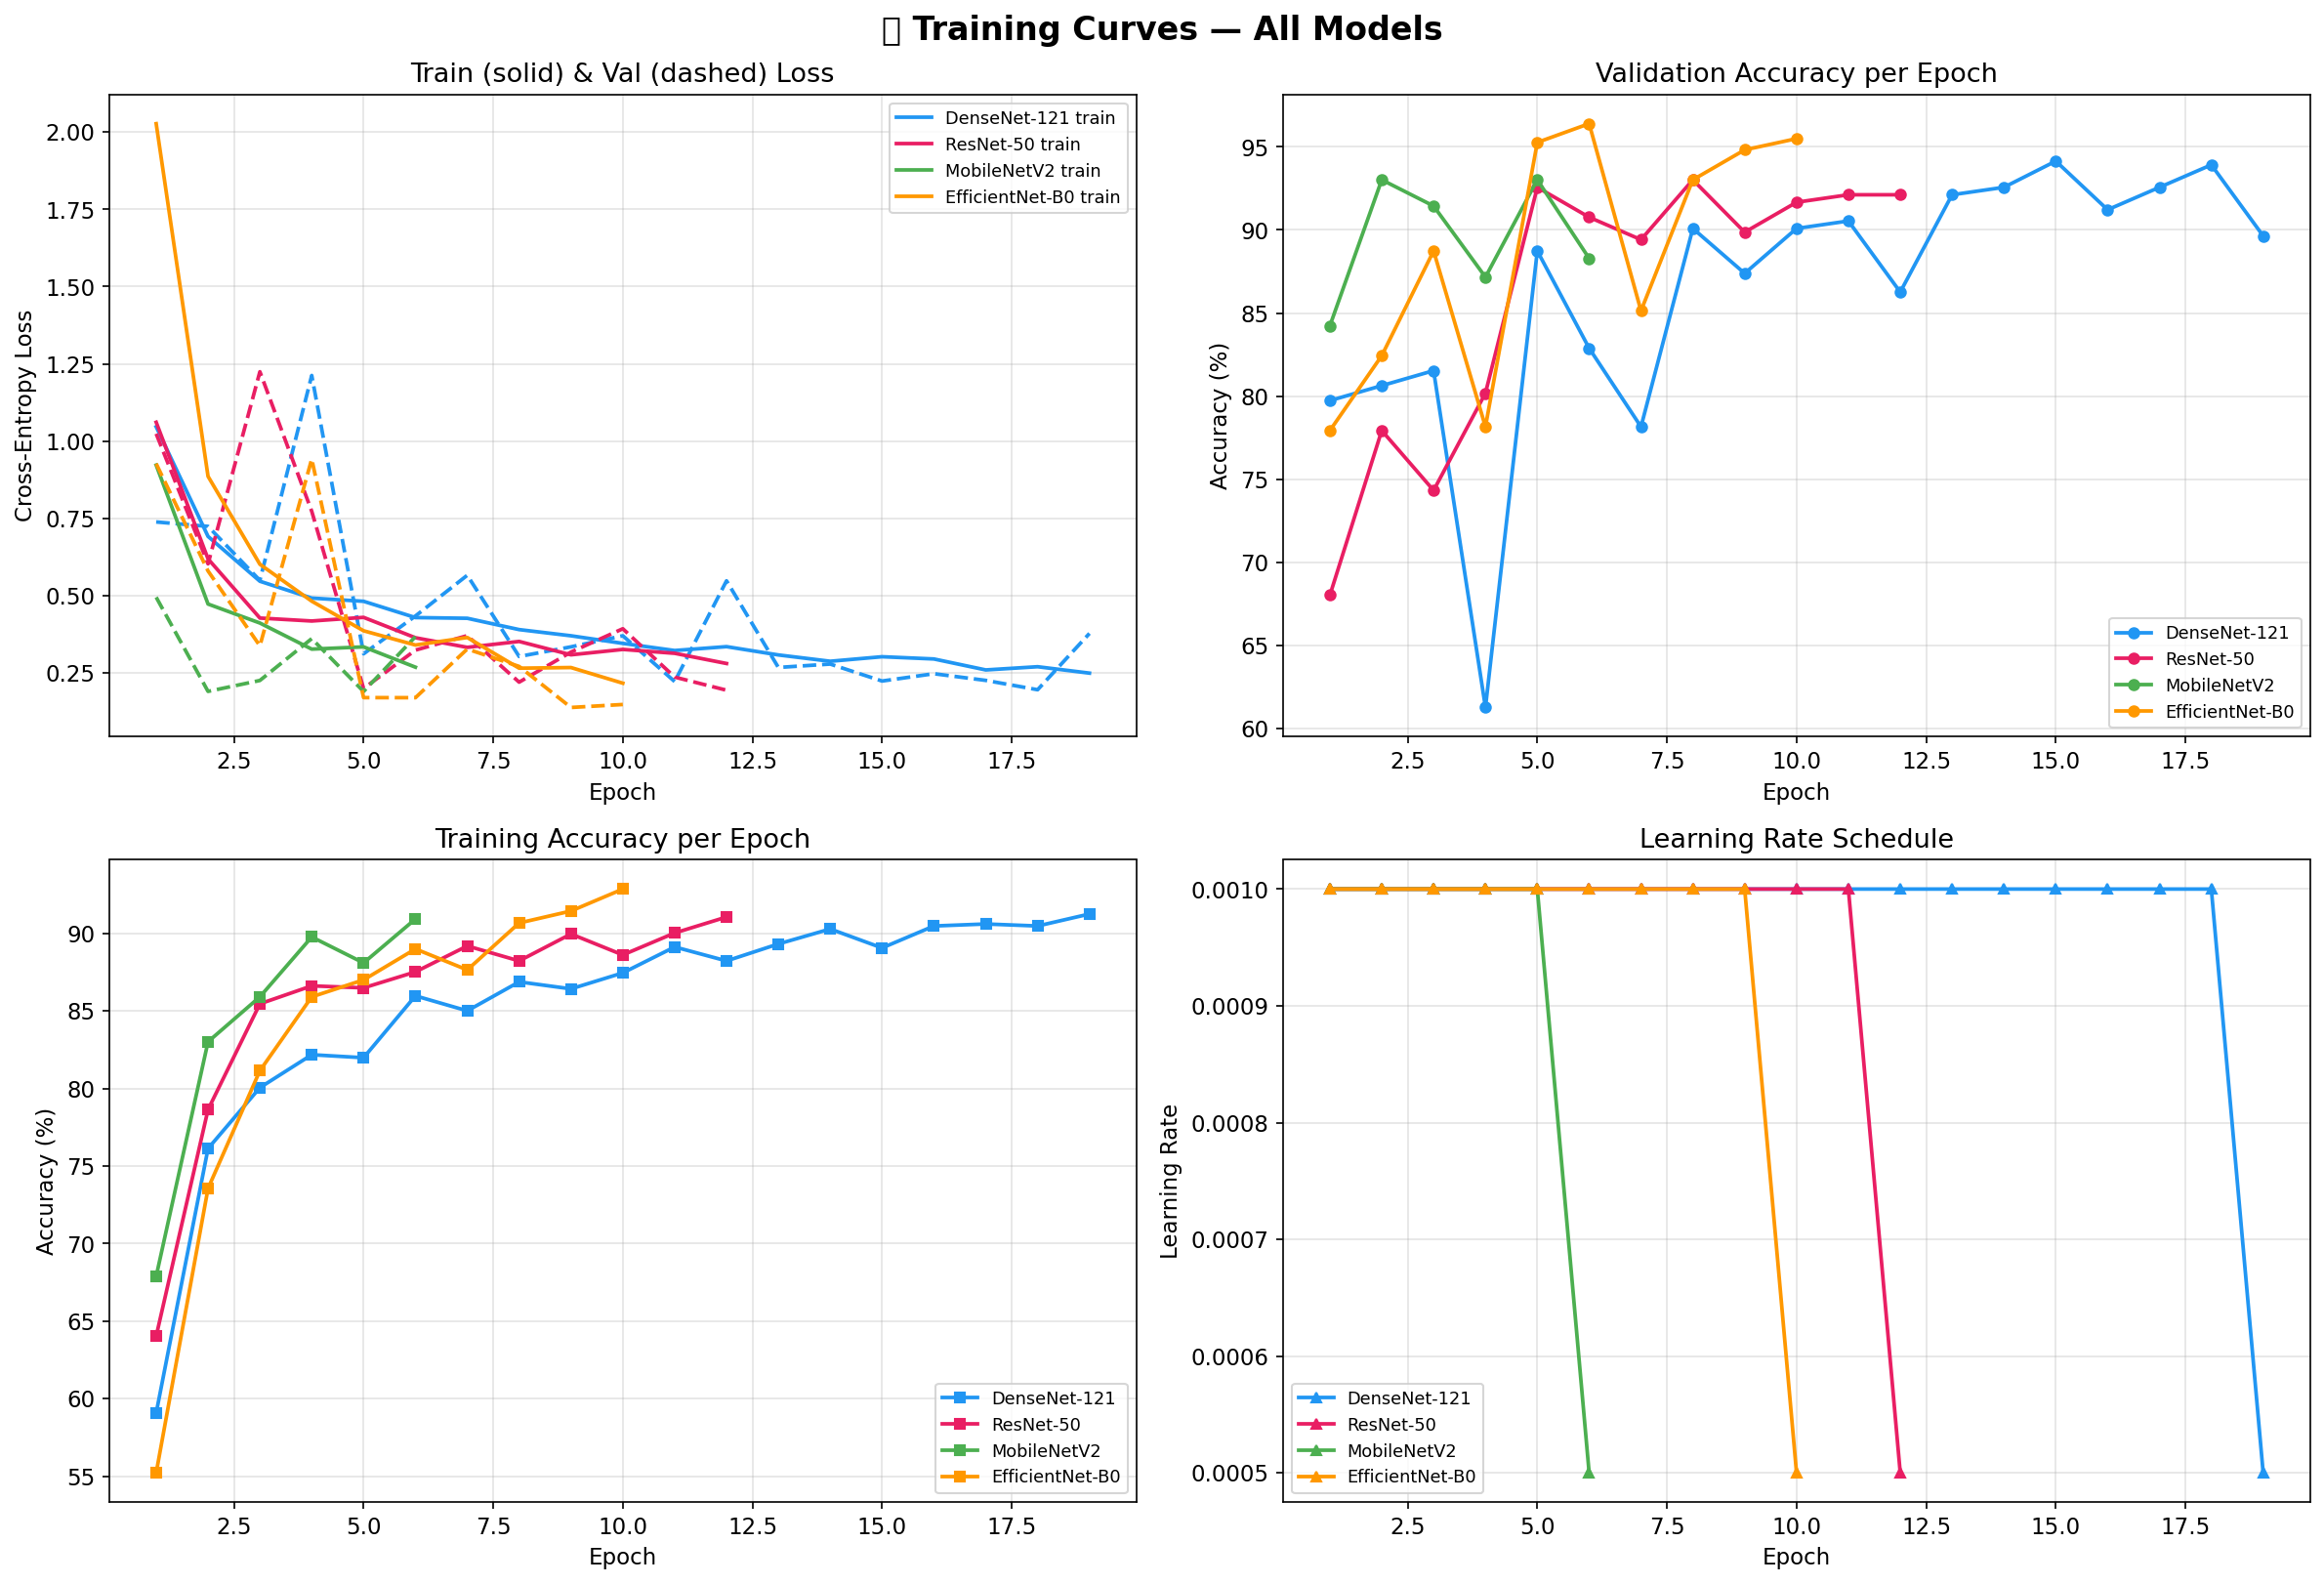

✅ Training curves saved.


In [36]:
# ============================================================
# RESULT 2 — TRAINING CURVES (LOSS & ACCURACY)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('📈 Training Curves — All Models', fontsize=16, fontweight='bold')
palette = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for i, (mname, res) in enumerate(training_results.items()):
    c = palette[i]
    ep = range(1, len(res['train_losses']) + 1)
    axes[0, 0].plot(ep, res['train_losses'], color=c, lw=1.8, label=f'{mname} train')
    axes[0, 0].plot(ep, res['val_losses'],   color=c, lw=1.8, ls='--')
    axes[0, 1].plot(ep, res['val_accs'],     color=c, lw=1.8, marker='o', ms=5, label=mname)
    axes[1, 0].plot(ep, res['train_accs'],   color=c, lw=1.8, marker='s', ms=5, label=mname)
    axes[1, 1].plot(ep, res['learning_rates'],color=c, lw=1.8, marker='^', ms=5, label=mname)

for ax, title, ylabel in [
    (axes[0, 0], 'Train (solid) & Val (dashed) Loss', 'Cross-Entropy Loss'),
    (axes[0, 1], 'Validation Accuracy per Epoch',     'Accuracy (%)'),
    (axes[1, 0], 'Training Accuracy per Epoch',       'Accuracy (%)'),
    (axes[1, 1], 'Learning Rate Schedule',            'Learning Rate'),
]:
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")

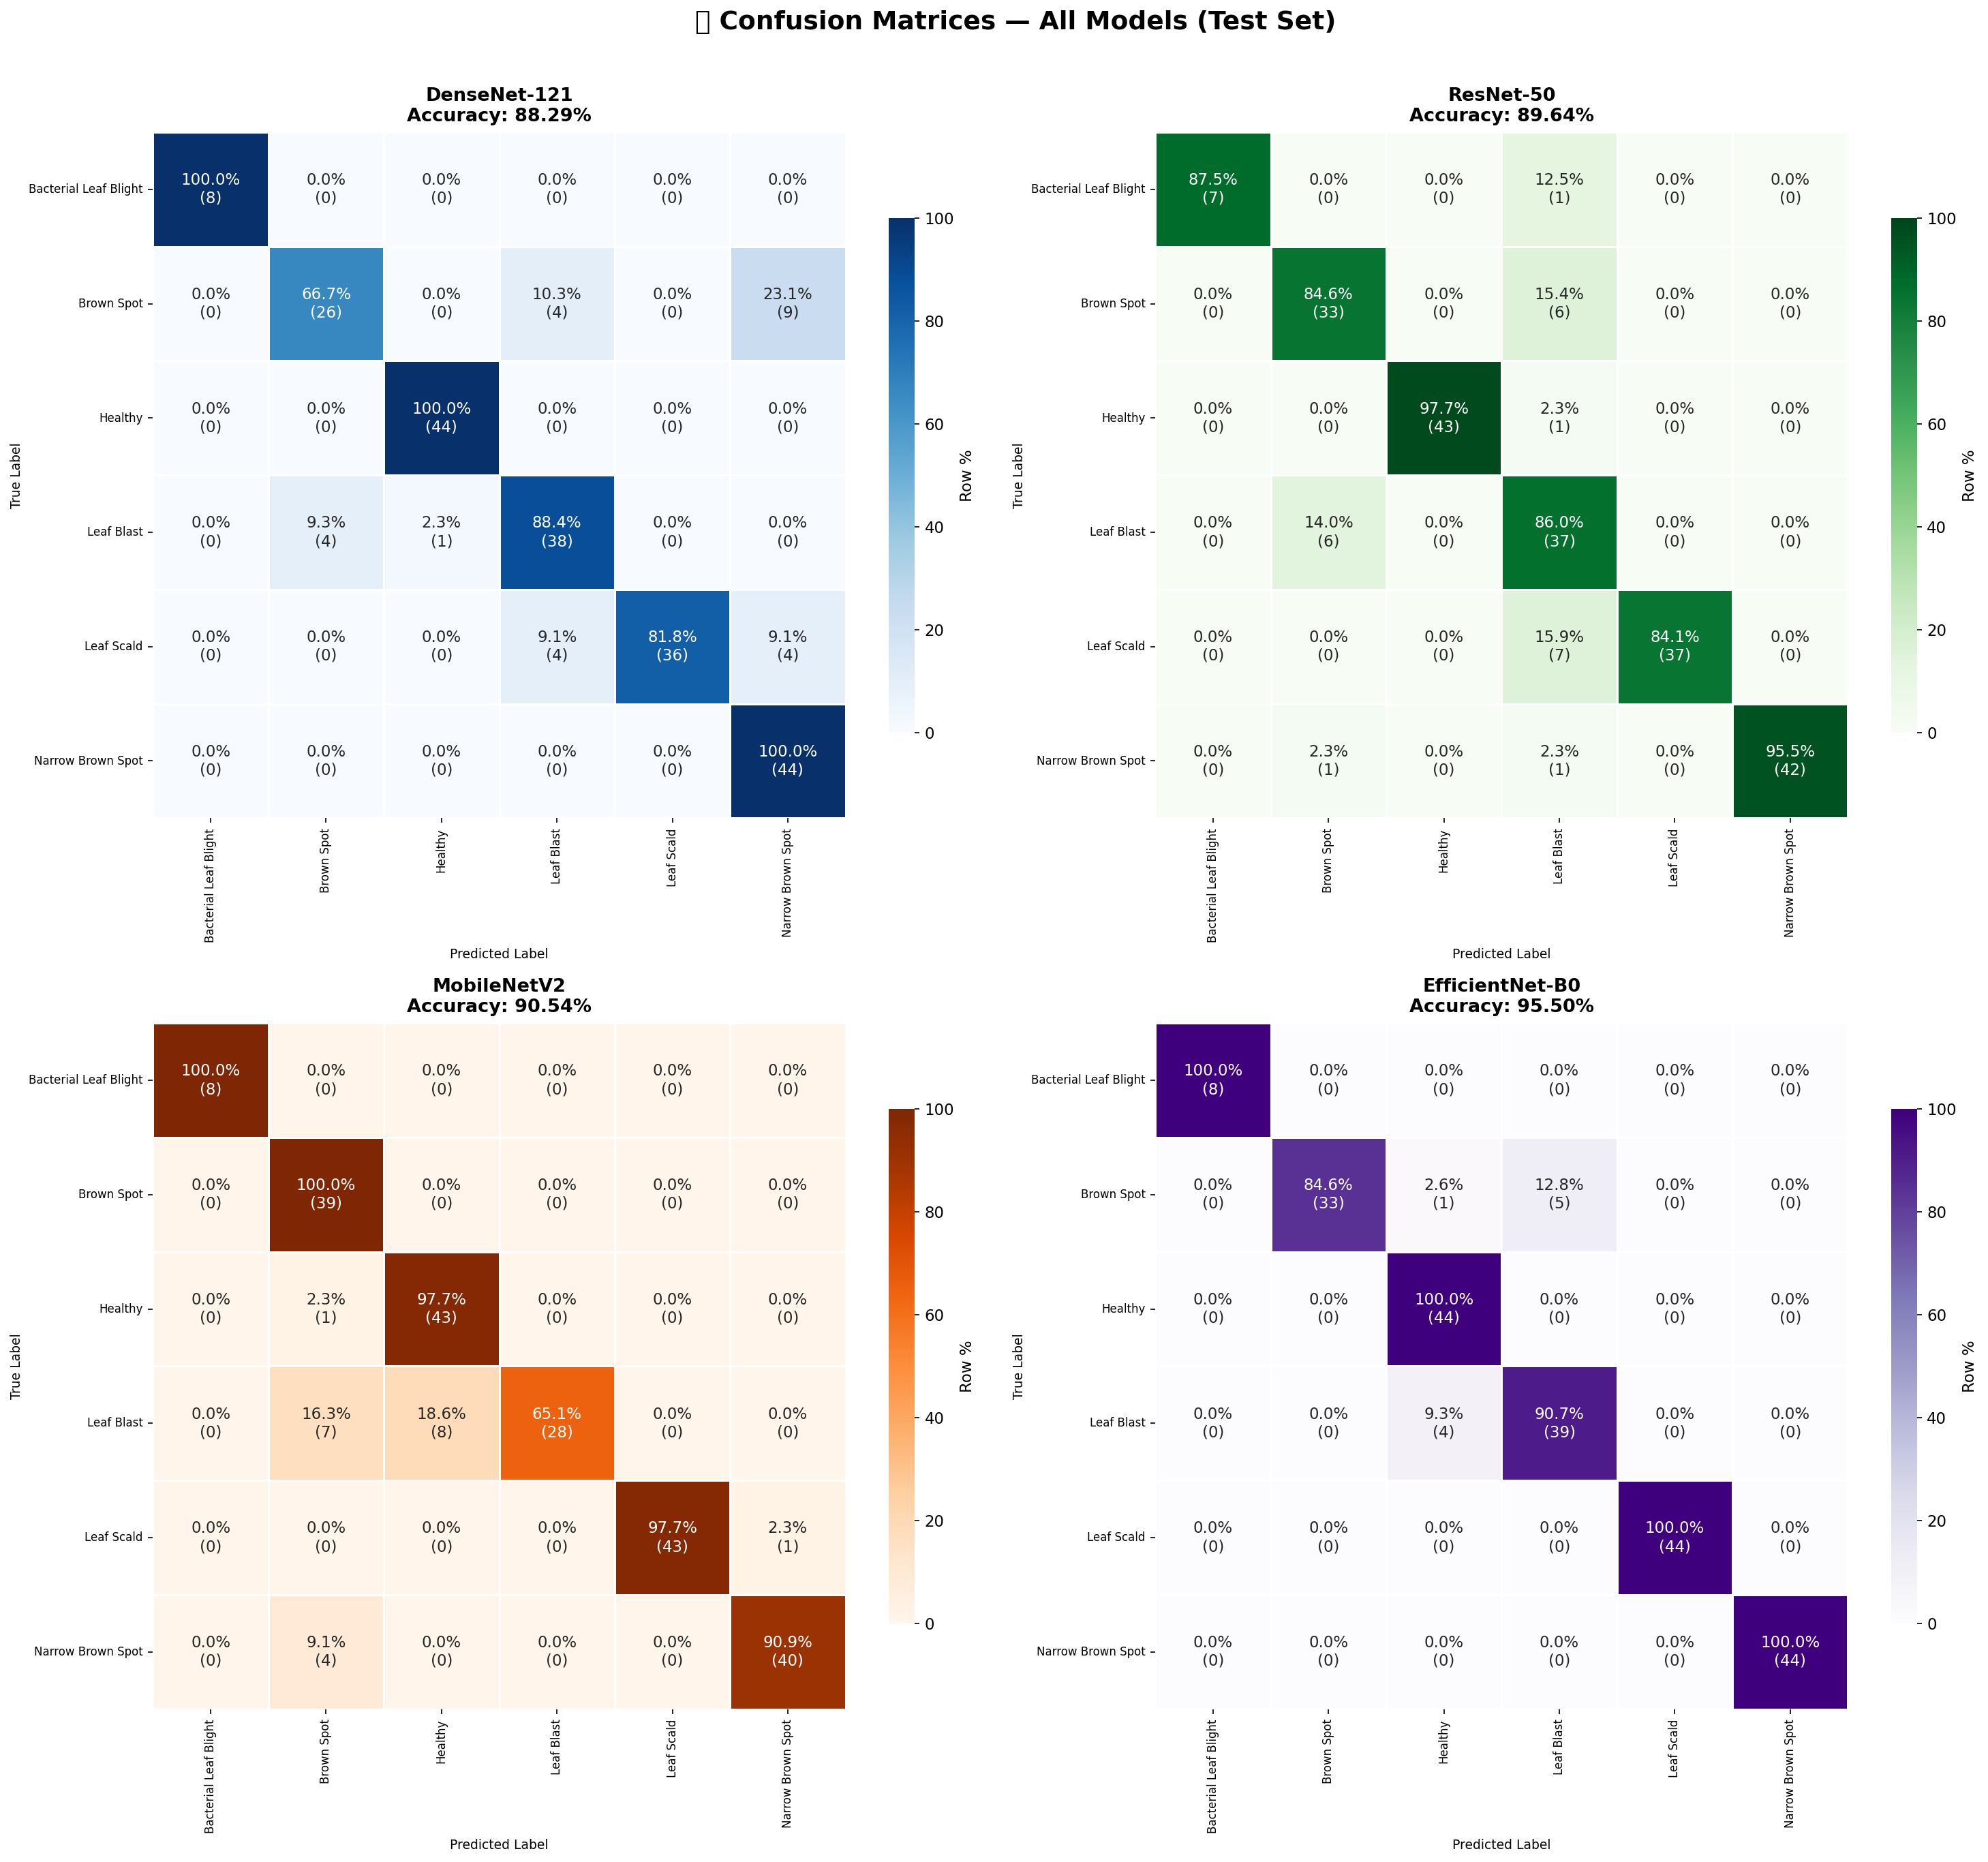

✅ Confusion matrices for ALL 4 models saved.


In [37]:
# ============================================================
# RESULT 3 — CONFUSION MATRICES (ALL 4 MODELS)
# ============================================================
CMAPS = ['Blues', 'Greens', 'Oranges', 'Purples']

def plot_confusion_matrix_single(ax, targets, preds, class_names, title, cmap='Blues'):
    cm     = confusion_matrix(targets, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f"{p:.1f}%\n({c})" for p, c in zip(row_p, row_c)]
                        for row_p, row_c in zip(cm_pct, cm)])
    sns.heatmap(cm_pct, ax=ax, annot=annot, fmt='', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Row %', 'shrink': 0.75},
                vmin=0, vmax=100)
    acc = accuracy_score(targets, preds) * 100
    ax.set_title(f"{title}\nAccuracy: {acc:.2f}%", fontweight='bold', pad=8)
    ax.set_ylabel('True Label', fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('🔍 Confusion Matrices — All Models (Test Set)',
             fontsize=18, fontweight='bold', y=1.01)

for idx, (mname, res) in enumerate(training_results.items()):
    plot_confusion_matrix_single(
        axes[idx // 2][idx % 2],
        res['targets'], res['predictions'],
        CLASS_NAMES, mname, CMAPS[idx]
    )

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices for ALL 4 models saved.")

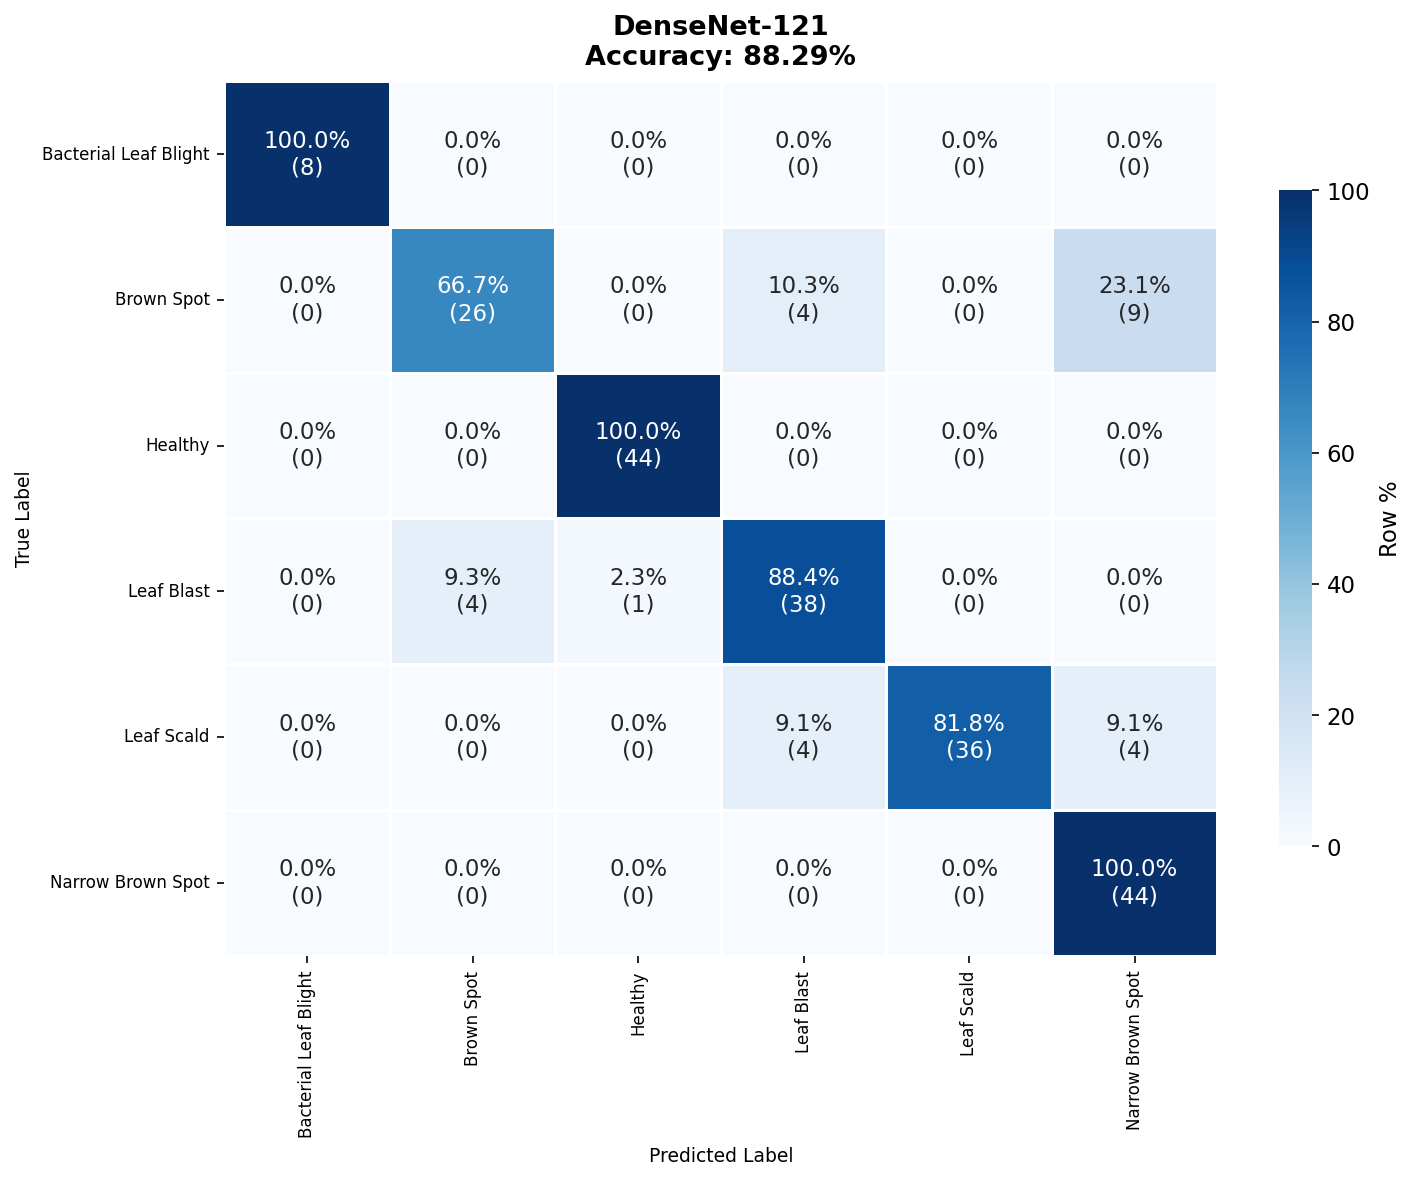

✅ DenseNet-121 saved as cm_densenet_121.png


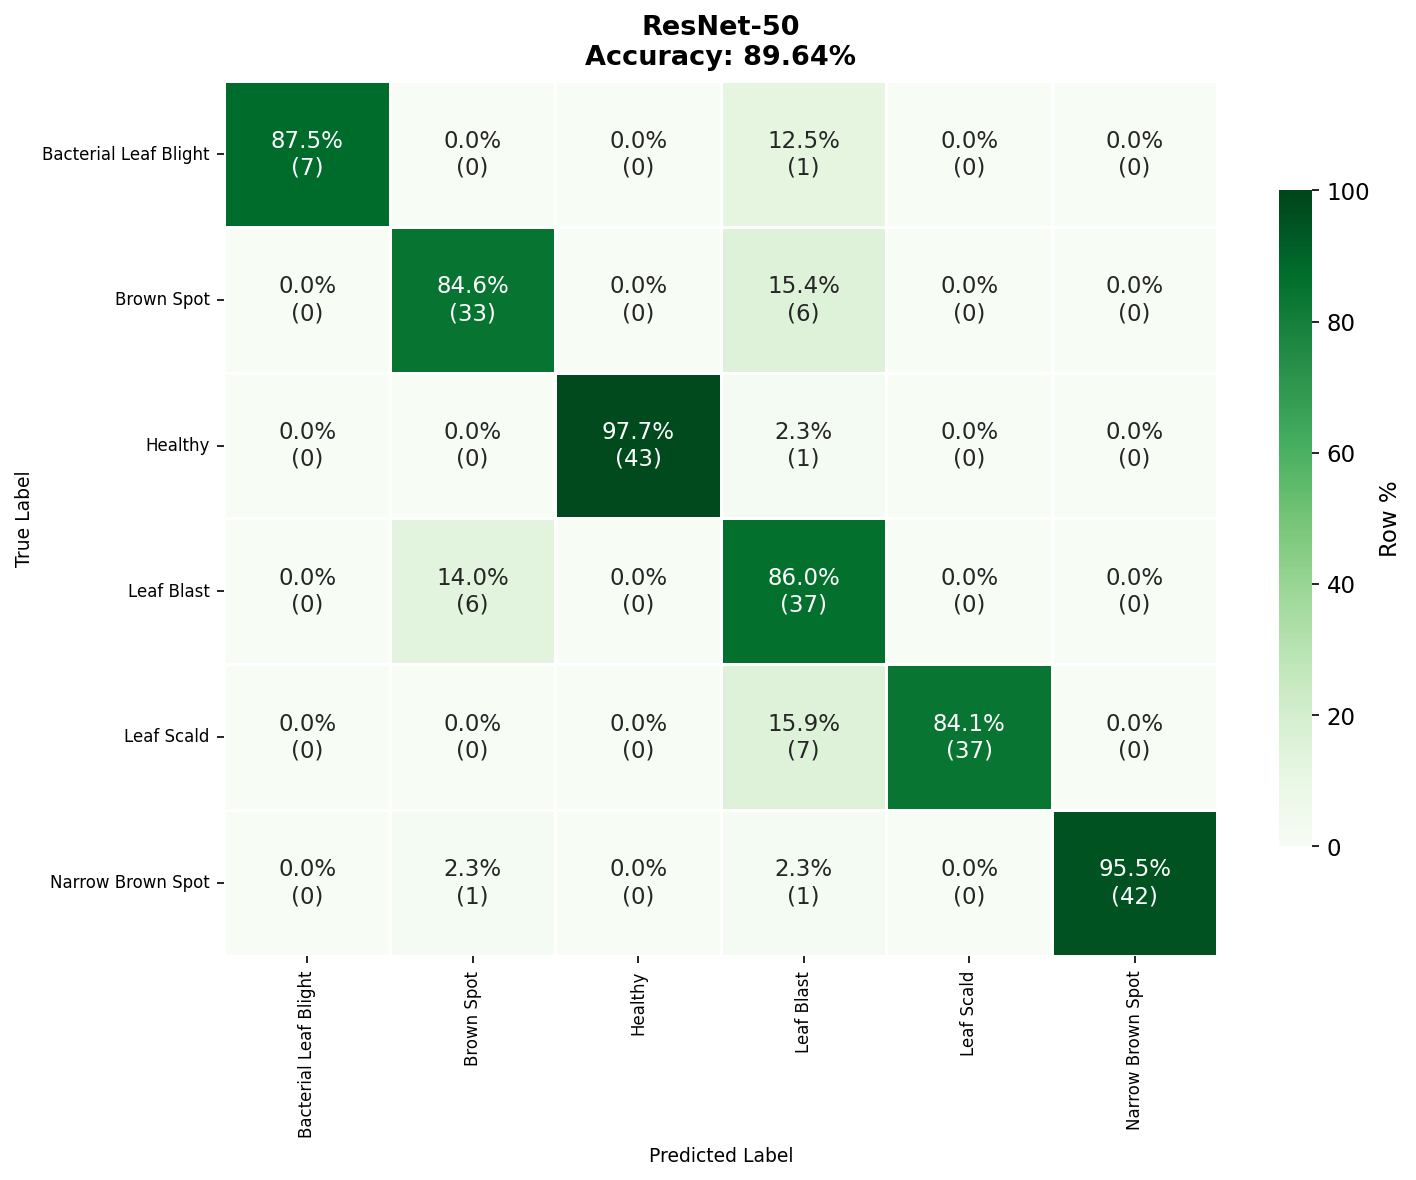

✅ ResNet-50 saved as cm_resnet_50.png


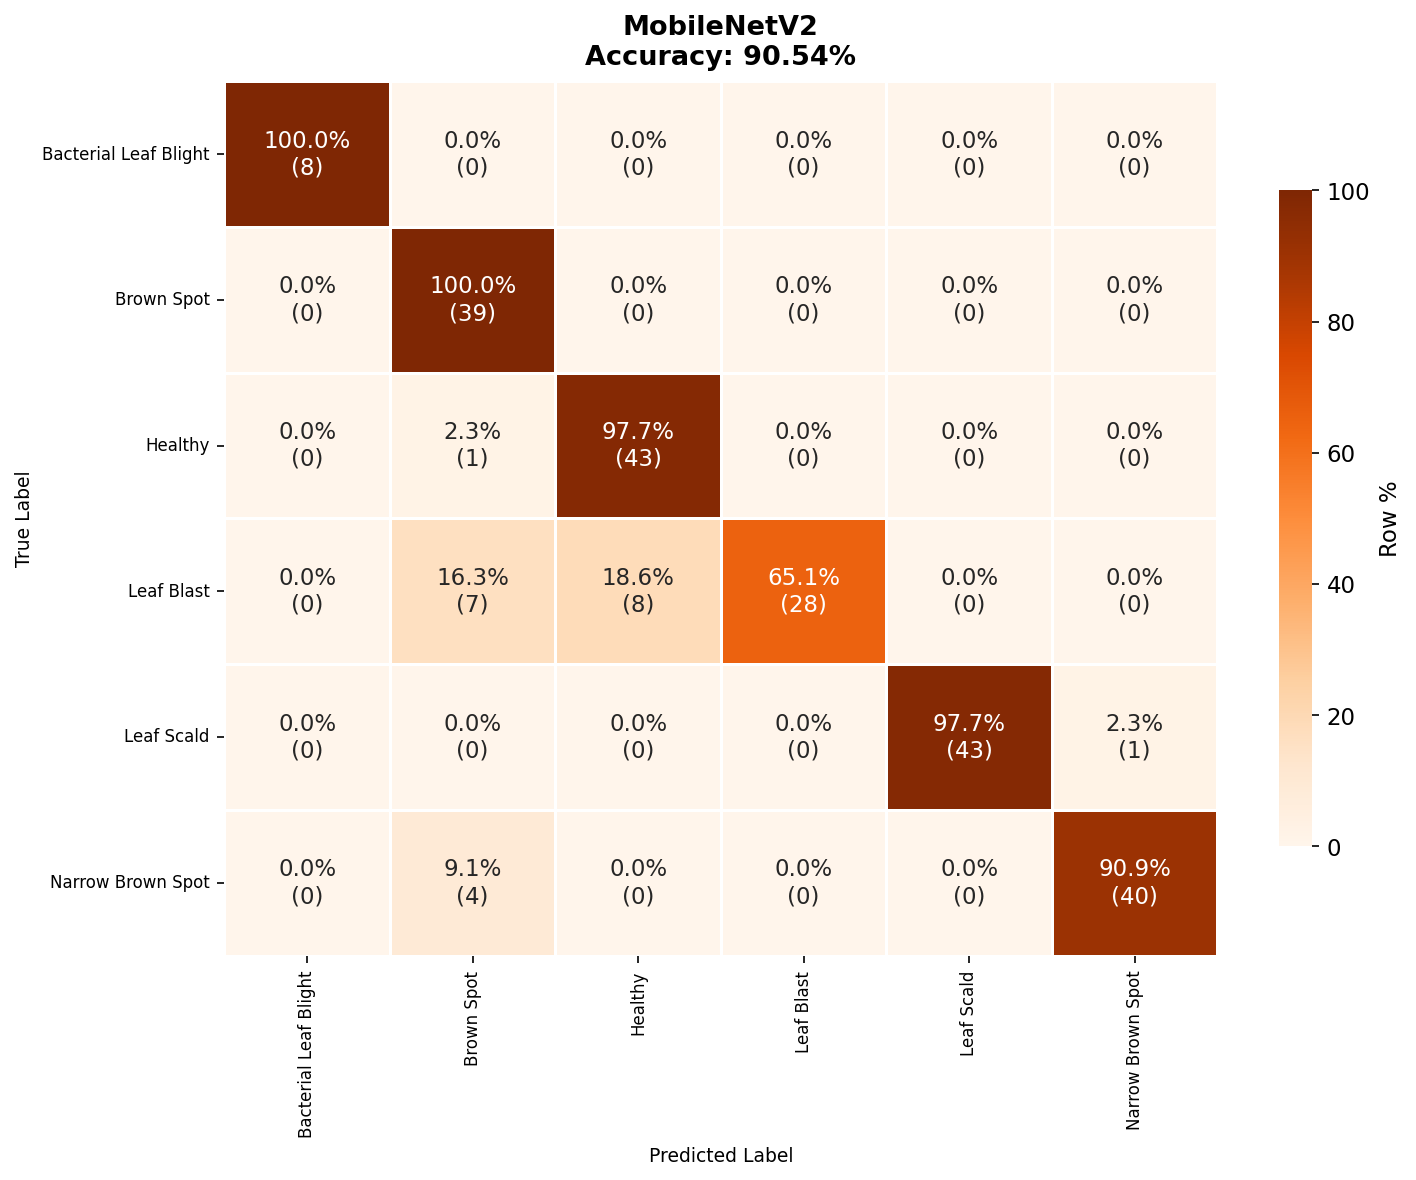

✅ MobileNetV2 saved as cm_mobilenetv2.png


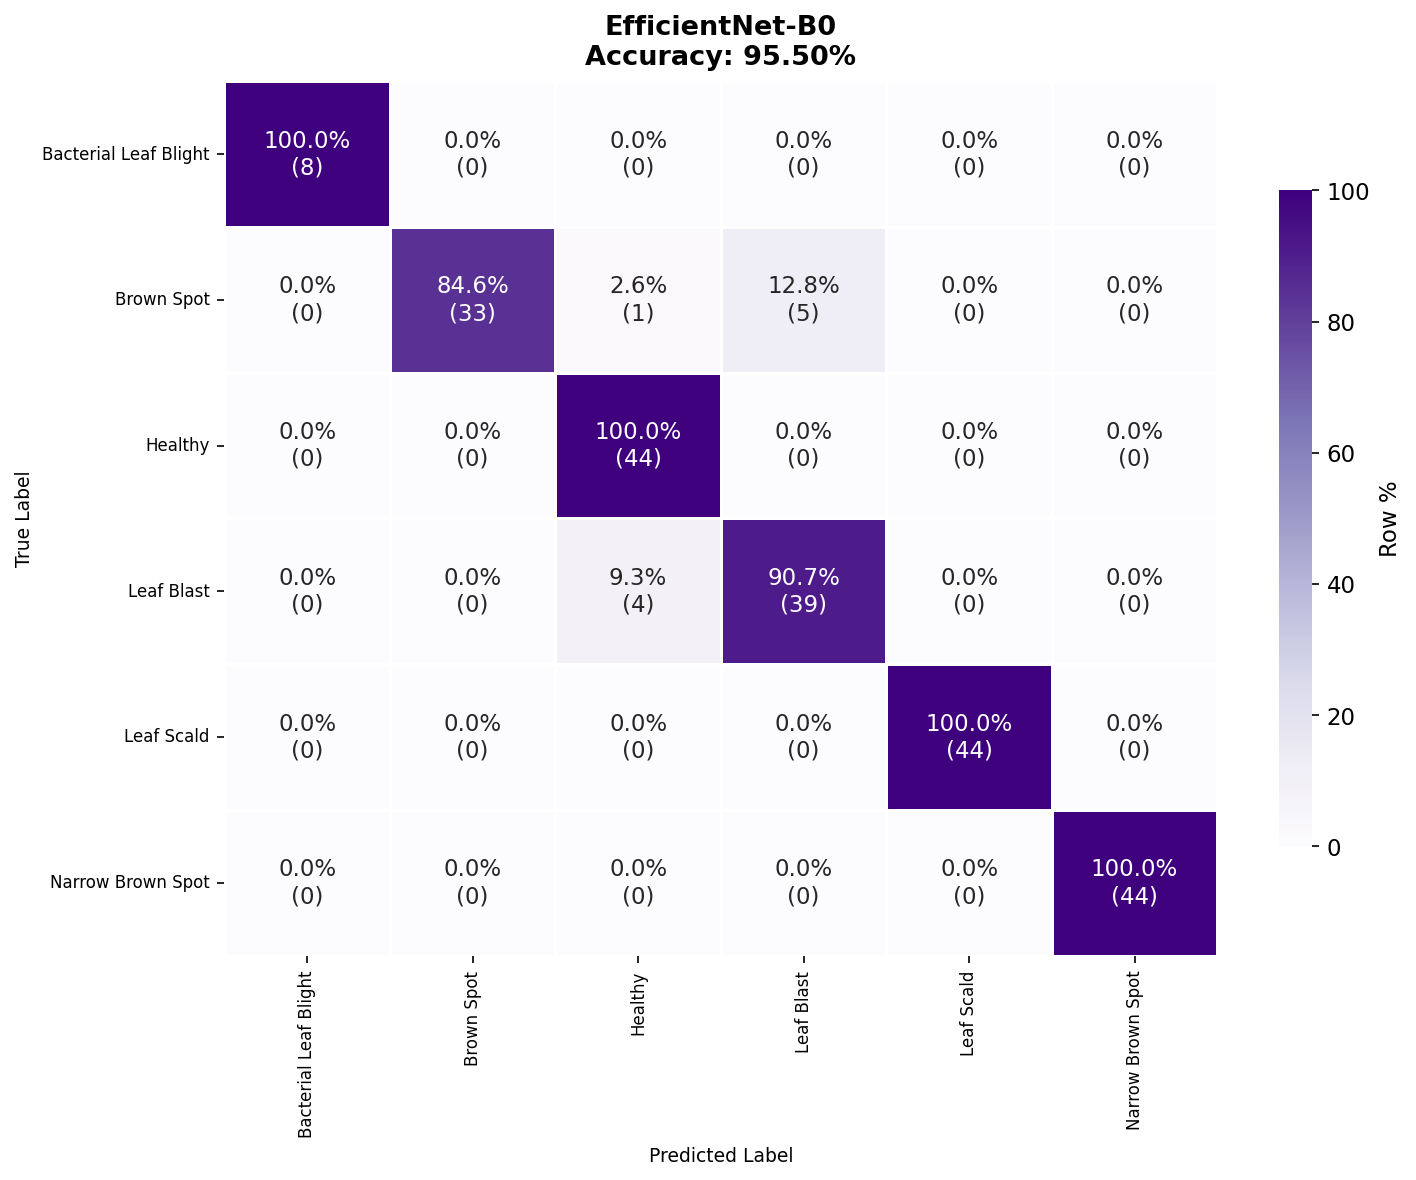

✅ EfficientNet-B0 saved as cm_efficientnet_b0.png


In [38]:
# ============================================================
# RESULT 4 — INDIVIDUAL HIGH-RES CONFUSION MATRICES
# ============================================================
for idx, (mname, res) in enumerate(training_results.items()):
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_confusion_matrix_single(ax, res['targets'], res['predictions'],
                                 CLASS_NAMES, mname, CMAPS[idx])
    fname = f"cm_{mname.replace('-','_').replace(' ','_').lower()}.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✅ {mname} saved as {fname}")

In [39]:
# ============================================================
# RESULT 5 — CLASSIFICATION REPORTS
# ============================================================
print("📋 PER-CLASS CLASSIFICATION REPORTS")
print("=" * 70)
for mname, res in training_results.items():
    print(f"\n── {mname} ──")
    print(classification_report(res['targets'], res['predictions'],
                                 target_names=CLASS_NAMES, digits=4))
print("=" * 70)

📋 PER-CLASS CLASSIFICATION REPORTS

── DenseNet-121 ──
                       precision    recall  f1-score   support

Bacterial Leaf Blight     1.0000    1.0000    1.0000         8
           Brown Spot     0.8667    0.6667    0.7536        39
              Healthy     0.9778    1.0000    0.9888        44
           Leaf Blast     0.8261    0.8837    0.8539        43
           Leaf Scald     1.0000    0.8182    0.9000        44
    Narrow Brown Spot     0.7719    1.0000    0.8713        44

             accuracy                         0.8829       222
            macro avg     0.9071    0.8948    0.8946       222
         weighted avg     0.8933    0.8829    0.8809       222


── ResNet-50 ──
                       precision    recall  f1-score   support

Bacterial Leaf Blight     1.0000    0.8750    0.9333         8
           Brown Spot     0.8250    0.8462    0.8354        39
              Healthy     1.0000    0.9773    0.9885        44
           Leaf Blast     0.6981    0.8605

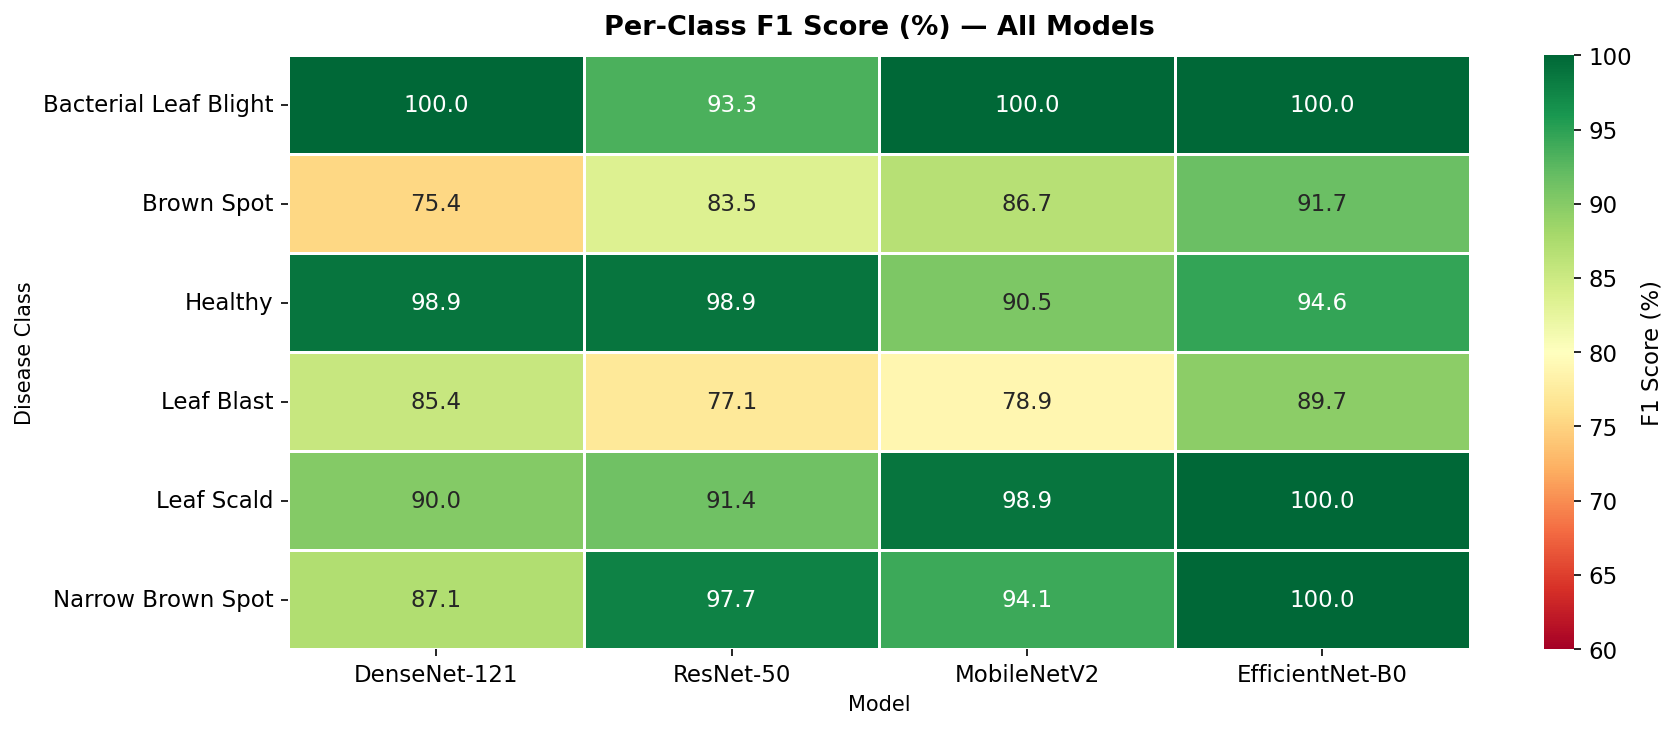

✅ Per-class F1 heatmap saved.


In [40]:
# ============================================================
# RESULT 6 — PER-CLASS F1 SCORE HEATMAP
# ============================================================
per_class_f1 = {
    mname: f1_score(res['targets'], res['predictions'], average=None) * 100
    for mname, res in training_results.items()
}
f1_df = pd.DataFrame(per_class_f1, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(12, max(5, len(CLASS_NAMES) * 0.8)))
sns.heatmap(f1_df, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=60, vmax=100, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'F1 Score (%)'})
ax.set_title('Per-Class F1 Score (%) — All Models', fontsize=13,
             fontweight='bold', pad=10)
ax.set_xlabel('Model', fontsize=10); ax.set_ylabel('Disease Class', fontsize=10)
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class F1 heatmap saved.")

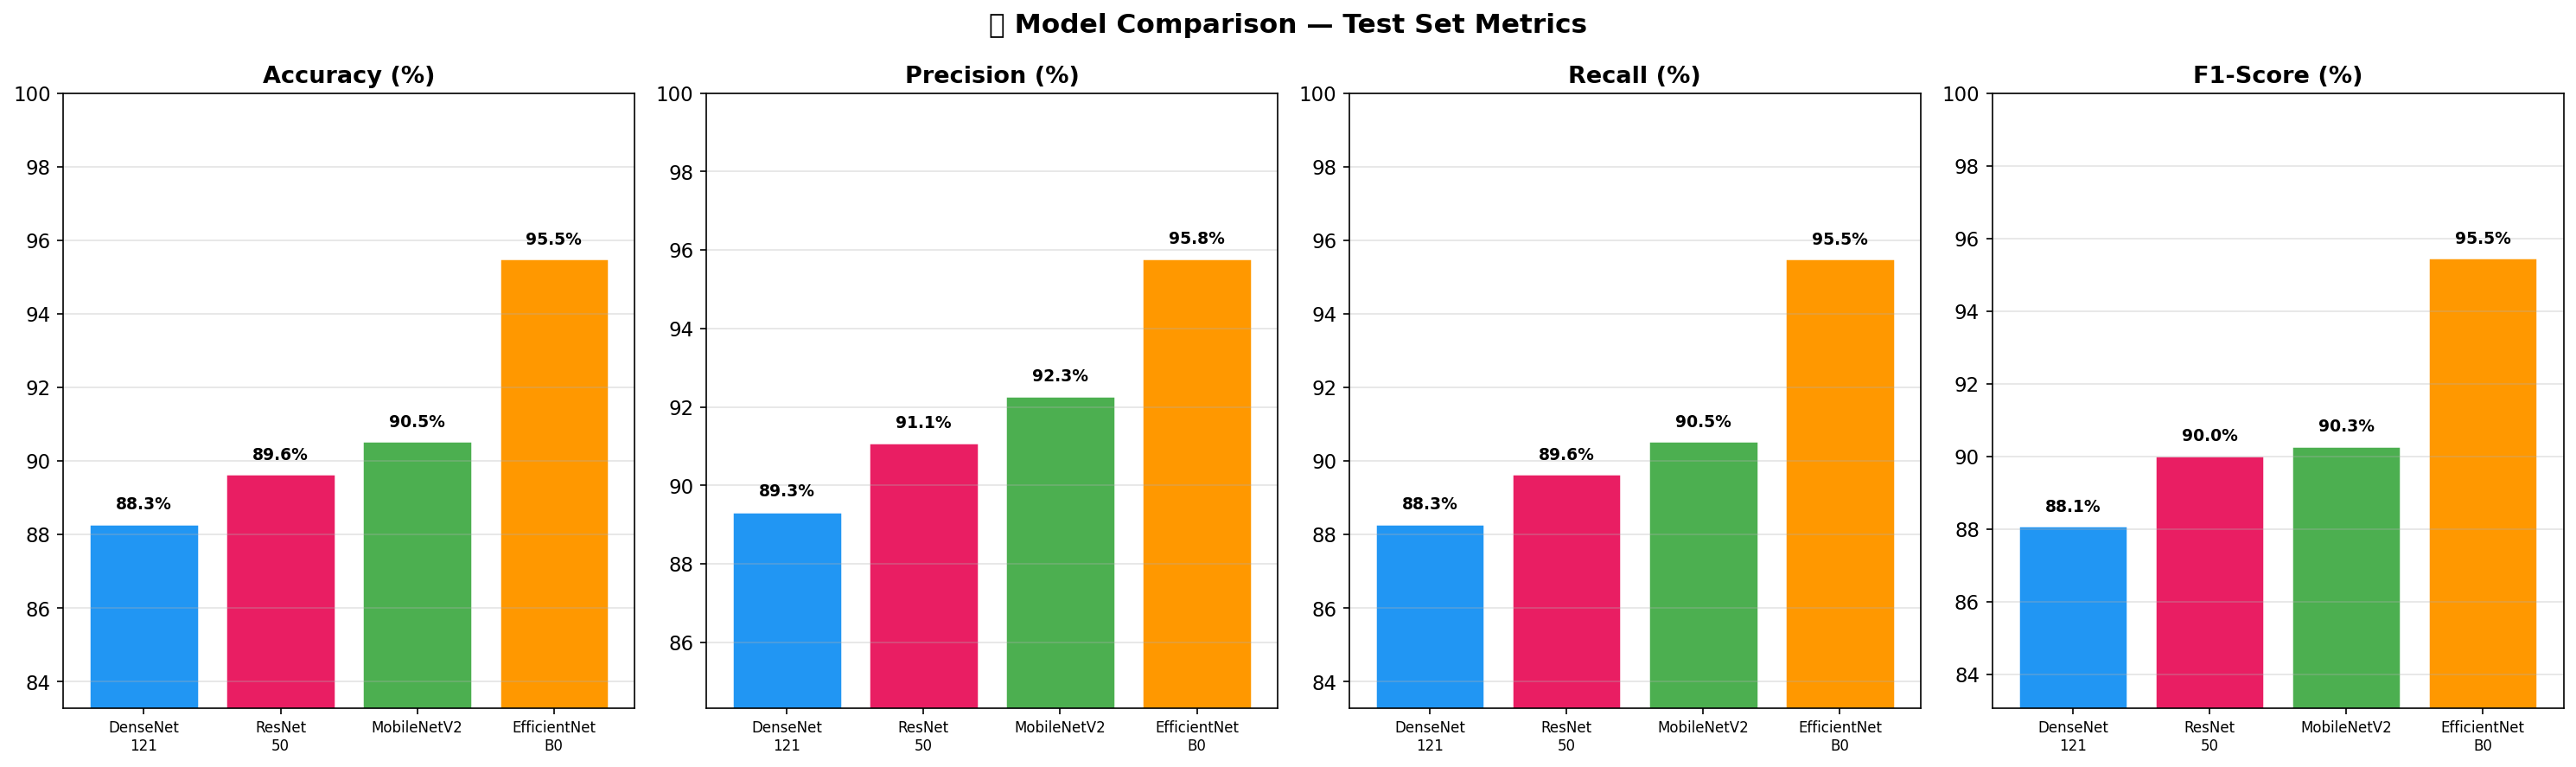

✅ Metric comparison chart saved.


In [41]:
# ============================================================
# RESULT 7 — METRIC COMPARISON BAR CHARTS
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('📊 Model Comparison — Test Set Metrics', fontsize=15, fontweight='bold')

metric_keys   = ['accuracy', 'precision', 'recall', 'f1_score']
metric_titles = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
bar_colors    = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']
model_names   = list(training_results.keys())

for ax, key, title in zip(axes, metric_keys, metric_titles):
    values = [training_results[m][key] for m in model_names]
    bars = ax.bar(range(len(model_names)), values, color=bar_colors,
                  edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=8)
    ax.set_ylim(max(0, min(values) - 5), 100)
    ax.grid(axis='y', alpha=0.35)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metric comparison chart saved.")

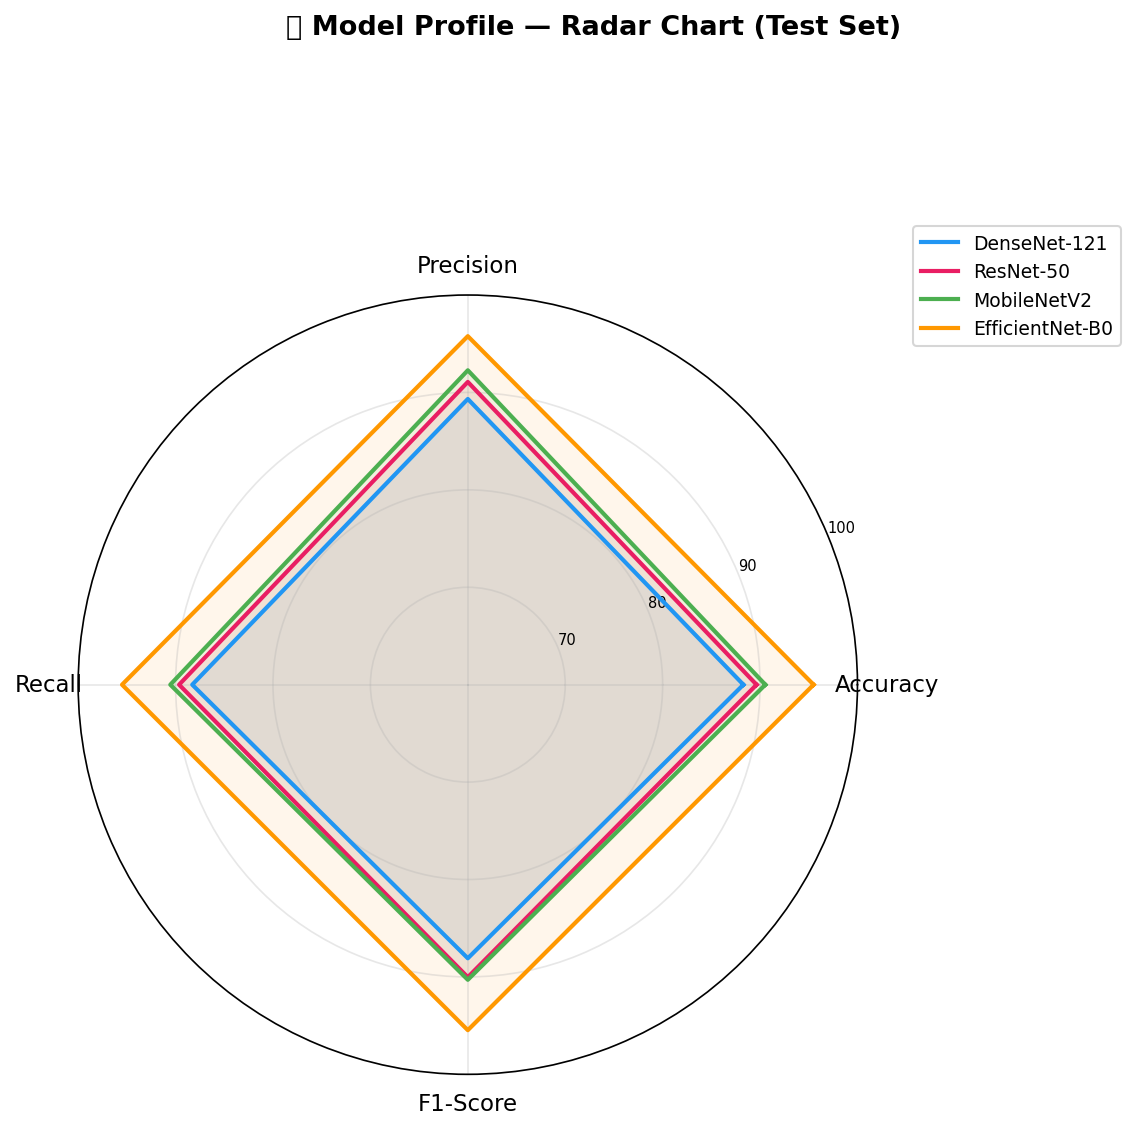

✅ Radar chart saved.


In [42]:
# ============================================================
# RESULT 8 — RADAR (SPIDER) CHART
# ============================================================
radar_metrics = ['accuracy', 'precision', 'recall', 'f1_score']
radar_labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + \
         [np.linspace(0, 2 * np.pi, N, endpoint=False)[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
fig.suptitle('🕷️ Model Profile — Radar Chart (Test Set)',
             fontsize=13, fontweight='bold', y=1.02)

for i, (mname, res) in enumerate(training_results.items()):
    vals = [res[m] for m in radar_metrics] + [res[radar_metrics[0]]]
    ax.plot(angles, vals, color=palette[i], lw=2, label=mname)
    ax.fill(angles, vals, color=palette[i], alpha=0.08)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(60, 100)
ax.set_yticks([70, 80, 90, 100])
ax.set_yticklabels(['70', '80', '90', '100'], fontsize=7)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Radar chart saved.")

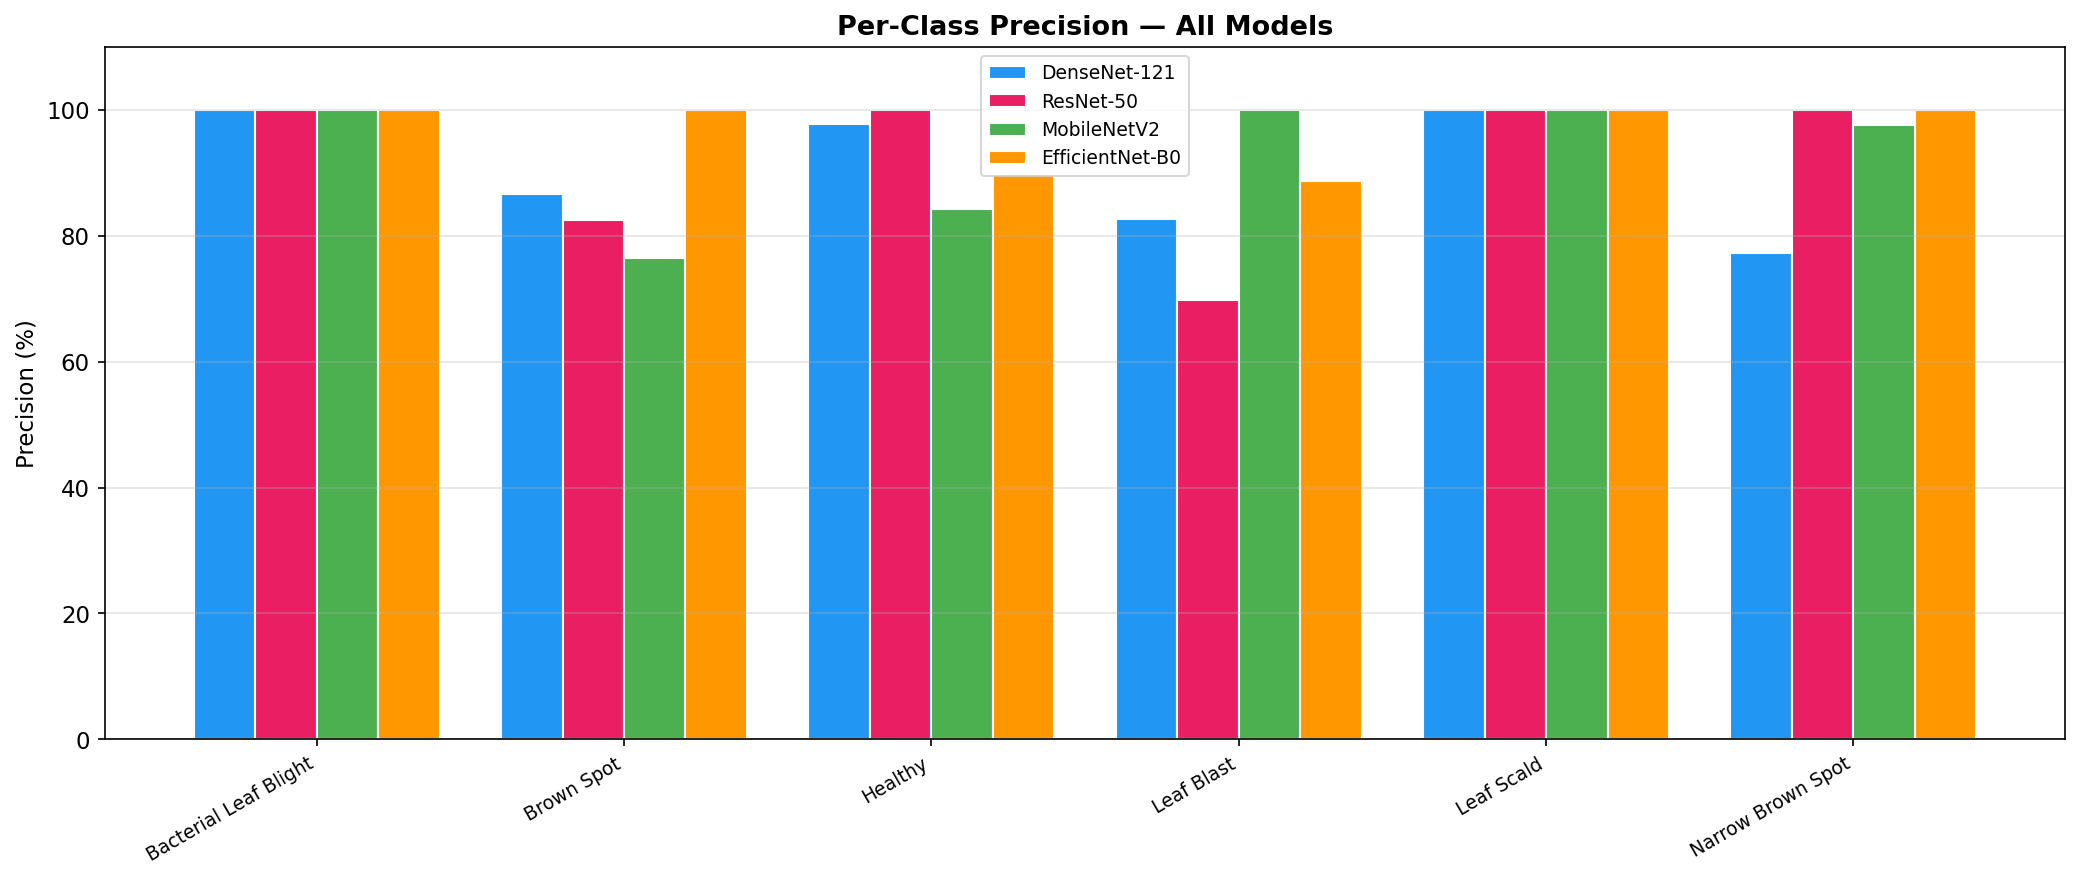

✅ Per-class Precision chart saved.


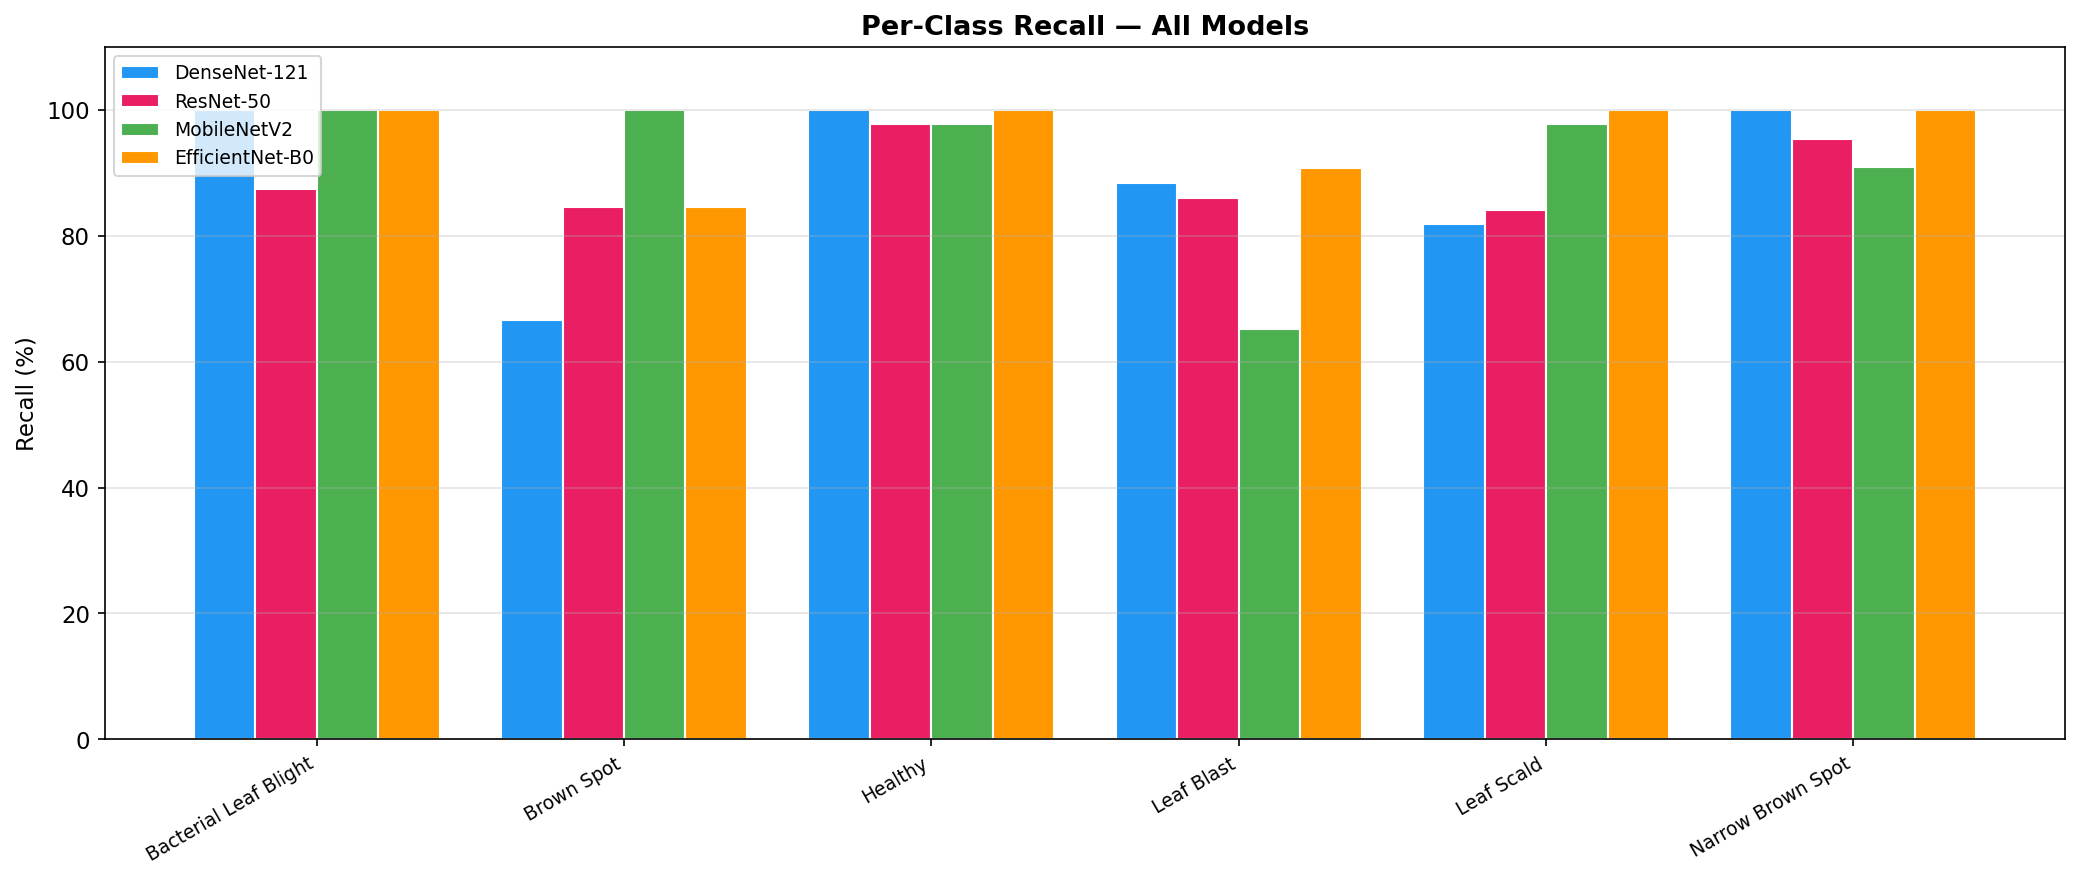

✅ Per-class Recall chart saved.


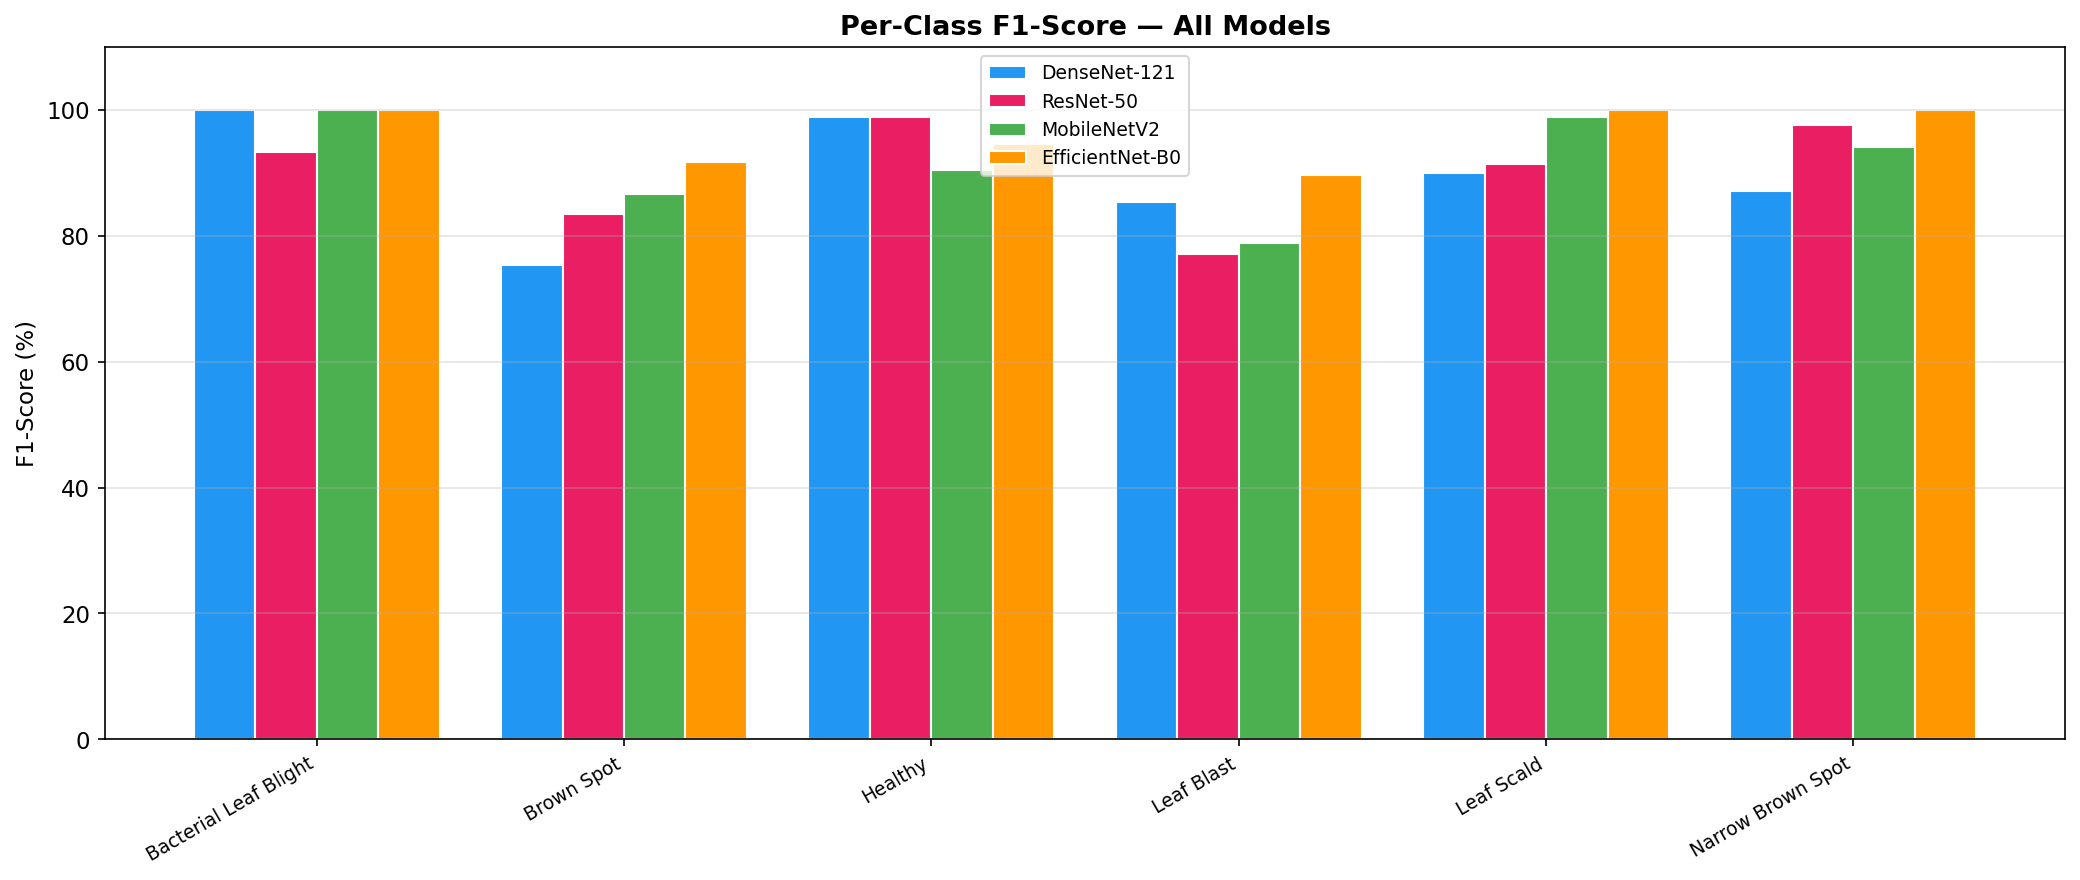

✅ Per-class F1-Score chart saved.


In [43]:
# ============================================================
# RESULT 9 — PER-CLASS PRECISION / RECALL / F1 GROUPED BAR
# ============================================================
for metric_key, metric_label, score_fn in [
    ('precision', 'Precision', lambda t, p: precision_score(t, p, average=None) * 100),
    ('recall',    'Recall',    lambda t, p: recall_score(t, p, average=None) * 100),
    ('f1',        'F1-Score',  lambda t, p: f1_score(t, p, average=None) * 100),
]:
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(CLASS_NAMES)); w = 0.20

    for i, (mname, res) in enumerate(training_results.items()):
        vals = score_fn(res['targets'], res['predictions'])
        ax.bar(x + i * w, vals, w, label=mname, color=palette[i], edgecolor='white')

    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric_label} (%)')
    ax.set_title(f'Per-Class {metric_label} — All Models', fontweight='bold')
    ax.set_ylim(0, 110); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.35)
    plt.tight_layout()
    plt.savefig(f'per_class_{metric_key}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Per-class {metric_label} chart saved.")

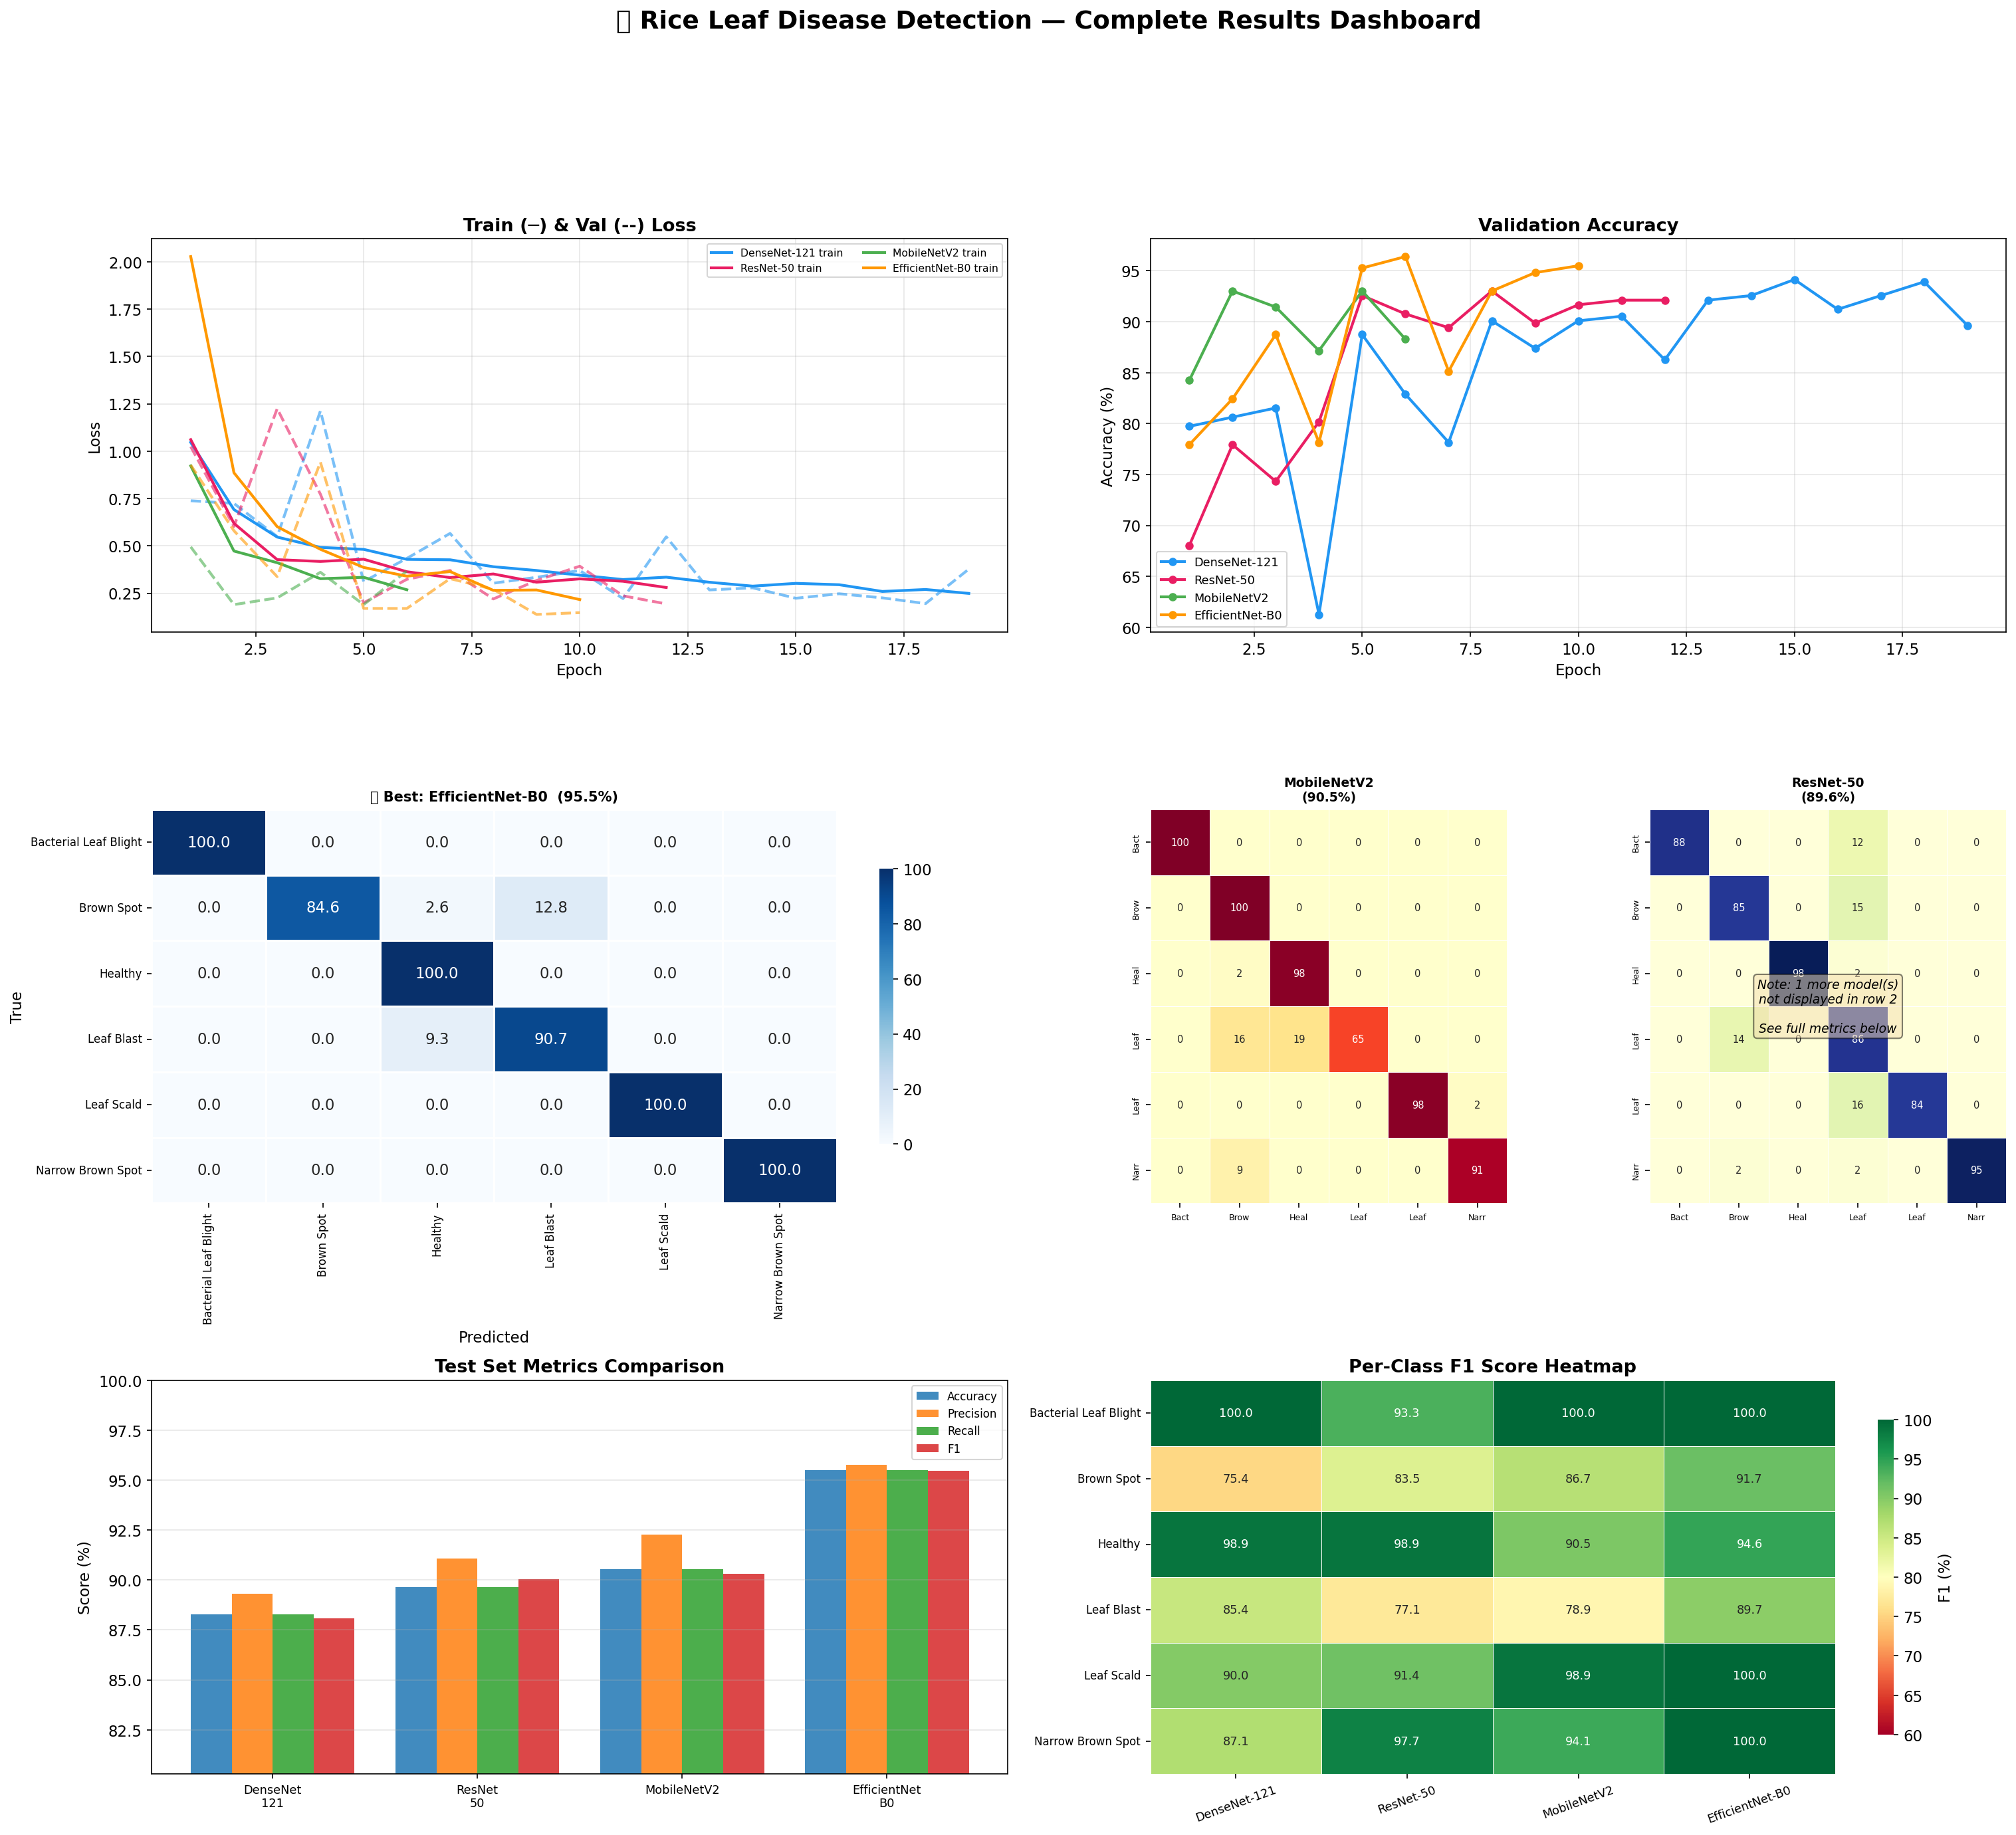

✅ Full results dashboard saved.


In [44]:
# ============================================================
# RESULT 10 — COMBINED DASHBOARD
# ============================================================
fig = plt.figure(figsize=(24, 20))
fig.suptitle('🌾 Rice Leaf Disease Detection — Complete Results Dashboard',
             fontsize=18, fontweight='bold', y=0.995)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.40)

# Row 1: Loss + Val Acc curves
ax_loss = fig.add_subplot(gs[0, :2])
ax_vacc = fig.add_subplot(gs[0, 2:])
for i, (mname, res) in enumerate(training_results.items()):
    c  = palette[i]
    ep = range(1, len(res['train_losses']) + 1)
    ax_loss.plot(ep, res['train_losses'], color=c, lw=2, label=f'{mname} train')
    ax_loss.plot(ep, res['val_losses'],   color=c, lw=2, ls='--', alpha=0.6)
    ax_vacc.plot(ep, res['val_accs'],     color=c, lw=2, marker='o', ms=5, label=mname)
ax_loss.set_title('Train (─) & Val (--) Loss', fontweight='bold')
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=7.5, ncol=2); ax_loss.grid(True, alpha=0.3)
ax_vacc.set_title('Validation Accuracy', fontweight='bold')
ax_vacc.set_xlabel('Epoch'); ax_vacc.set_ylabel('Accuracy (%)')
ax_vacc.legend(fontsize=8.5); ax_vacc.grid(True, alpha=0.3)

# Row 2: Best model CM + remaining models (adjust for variable number of models)
sorted_models = sorted(training_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
ax_cm_best = fig.add_subplot(gs[1, :2])
best_n, best_r = sorted_models[0]
cm_best = confusion_matrix(best_r['targets'], best_r['predictions'])
cm_pct  = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, ax=ax_cm_best, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'shrink': 0.7}, linewidths=0.5, linecolor='white')
ax_cm_best.set_title(f'🏆 Best: {best_n}  ({best_r["accuracy"]:.1f}%)',
                     fontweight='bold', fontsize=10)
ax_cm_best.set_xlabel('Predicted'); ax_cm_best.set_ylabel('True')
ax_cm_best.tick_params(labelsize=8)

# Display remaining models in available subplots
remaining_models = sorted_models[1:]
for j, (mname, res) in enumerate(remaining_models):
    # Check if we have space (max 2 models in row 2, columns 2 and 3)
    if j >= 2:
        break  # Skip if more than 2 remaining models
    ax_mini = fig.add_subplot(gs[1, 2 + j])
    cm_m  = confusion_matrix(res['targets'], res['predictions'])
    cm_mp = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True) * 100
    
    # Use different colormaps for each mini heatmap
    mini_cmaps = ['YlOrRd', 'YlGnBu', 'PuRd', 'Oranges']
    sns.heatmap(cm_mp, ax=ax_mini, annot=True, fmt='.0f', cmap=mini_cmaps[j % len(mini_cmaps)],
                xticklabels=[c[:4] for c in CLASS_NAMES],
                yticklabels=[c[:4] for c in CLASS_NAMES],
                cbar=False, linewidths=0.4, linecolor='white', annot_kws={'size': 7})
    ax_mini.set_title(f'{mname}\n({res["accuracy"]:.1f}%)', fontweight='bold', fontsize=9)
    ax_mini.tick_params(labelsize=6)

# If there are more than 3 total models (best + 2), add a note
if len(sorted_models) > 3:
    ax_note = fig.add_subplot(gs[1, 3])
    ax_note.axis('off')
    remaining_count = len(sorted_models) - 3
    ax_note.text(0.5, 0.5, f'Note: {remaining_count} more model(s)\nnot displayed in row 2\n\nSee full metrics below',
                ha='center', va='center', fontsize=9, style='italic',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Row 3: Metric bars + F1 heatmap
ax_bars = fig.add_subplot(gs[2, :2])
bar_x = np.arange(len(model_names)); bar_w = 0.20
for mi, (key, label) in enumerate(zip(['accuracy','precision','recall','f1_score'],
                                       ['Accuracy','Precision','Recall','F1'])):
    vals = [training_results[m][key] for m in model_names]
    ax_bars.bar(bar_x + mi * bar_w, vals, bar_w, label=label, alpha=0.85)
ax_bars.set_xticks(bar_x + bar_w * 1.5)
ax_bars.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=8.5)
ax_bars.set_ylabel('Score (%)')
ax_bars.set_title('Test Set Metrics Comparison', fontweight='bold')
ax_bars.set_ylim(max(0, min([training_results[m]['accuracy'] for m in model_names]) - 8), 100)
ax_bars.legend(fontsize=8); ax_bars.grid(axis='y', alpha=0.3)

ax_heat = fig.add_subplot(gs[2, 2:])
sns.heatmap(f1_df, ax=ax_heat, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=60, vmax=100, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'F1 (%)', 'shrink': 0.8}, annot_kws={'size': 8.5})
ax_heat.set_title('Per-Class F1 Score Heatmap', fontweight='bold')
ax_heat.tick_params(axis='x', labelsize=8.5, rotation=20)
ax_heat.tick_params(axis='y', labelsize=8)

plt.savefig('results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full results dashboard saved.")